# Hypotension obs24_target8_gap0 Cluster Visualization

Load saved autoencoder embeddings, cluster assignments, importance maps, and prepared tensors for the `vit_baseline/obs24_target8_gap0/hypotension` run, then render cluster heatmaps with normal-range coloring.

## Imports and Paths

In [1]:
from __future__ import annotations

import json
import logging
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "interpretable_ts_vit").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from interpretable_ts_vit.binning import TimeSeriesBinner
from interpretable_ts_vit.io import load_split
from interpretable_ts_vit.visualization import (
    aggregate_cluster_value_matrices,
    cluster_assignment_counts,
    patient_value_matrix,
    plot_importance_heatmap,
    plot_value_heatmap,
    value_ranges_by_variable,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(name)s: %(message)s",
    force=True,
)
logger = logging.getLogger("hypotension_cluster_visualization")
logger.info("Project root: %s", PROJECT_ROOT)

2026-07-15 18:16:11,187 INFO hypotension_cluster_visualization: Project root: /home/michalwe/Interpretable-ViT-for-Timeseries


In [2]:
EXPERIMENT_NAME = "vit_baseline"
TARGET = "hypotension"
WINDOW = "obs24_target8_gap0"
SPLIT = "test"

RUN_DIR = PROJECT_ROOT / "runs" / "mimic_targets" / EXPERIMENT_NAME / WINDOW / TARGET
PROCESSED_DIR = PROJECT_ROOT / "data" / "mimic_targets" / "processed" / WINDOW / TARGET
CLUSTERS_DIR = RUN_DIR / "clusters" / SPLIT
EXPLANATIONS_DIR = RUN_DIR / "explanations" / SPLIT
OUTPUT_DIR = RUN_DIR / "cluster_heatmaps" / SPLIT
SELECTED_OUTPUT_DIR = RUN_DIR / "selected_cluster_heatmaps" / SPLIT
SELECTED_PATIENT_OUTPUT_DIR = RUN_DIR / "selected_patient_heatmaps" / SPLIT
NORMAL_RANGES_PATH = PROJECT_ROOT / "src" / "interpretable_ts_vit" / "normal_ranges.json"

PLOT_MODE = "value_with_importance_opacity"
IMPORTANCE_THRESHOLD = None
TOP_IMPORTANCE_PERCENTAGE = 0.1
SELECT_BEST_N_CLUSTERS = True
N_CLUSTER_CANDIDATES = range(2, 13)
SHOW_VALUES = True
USE_NORMAL_RANGES = True

RUN_DIR

PosixPath('/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension')

## Load Saved Artifacts

In [3]:
def require_artifacts(paths):
    missing = [f"{name}: {path}" for name, path in paths.items() if not Path(path).exists()]
    if missing:
        raise FileNotFoundError("Missing required artifact(s):\n" + "\n".join(missing))


def safe_path_component(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_") or "class"


def embedding_feature_columns(embedding_frame):
    return [column for column in embedding_frame.columns if column != "patient_id"]


def nearest_centroid_flags(labels, distances):
    flags = np.zeros(len(labels), dtype=bool)
    for label in sorted(set(labels)):
        indices = np.where(labels == label)[0]
        if len(indices) == 0:
            continue
        flags[indices[np.argmin(distances[indices])]] = True
    return flags.tolist()


def cluster_frame_for_class(group, feature_columns, n_clusters, random_state=13):
    x = group[feature_columns].to_numpy(dtype=np.float64)
    scaled = StandardScaler().fit_transform(x)
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(scaled).astype(int)
    distances = np.linalg.norm(scaled - kmeans.cluster_centers_[labels], axis=1)
    return pd.DataFrame({
        "patient_id": group["patient_id"].astype(str).to_numpy(),
        "predicted_label": str(group["predicted_label"].iloc[0]),
        "cluster": labels,
        "distance_to_centroid": distances,
        "is_centroid": nearest_centroid_flags(labels, distances),
    })


def silhouette_scores_for_class(group, feature_columns, candidate_clusters, random_state=13):
    x = group[feature_columns].to_numpy(dtype=np.float64)
    scaled = StandardScaler().fit_transform(x)
    rows = []
    for candidate in candidate_clusters:
        n_clusters = int(candidate)
        if n_clusters < 2 or n_clusters >= len(group):
            continue
        labels = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10).fit_predict(scaled)
        rows.append({
            "predicted_label": str(group["predicted_label"].iloc[0]),
            "n_clusters": n_clusters,
            "silhouette_score": float(silhouette_score(scaled, labels)),
            "n_patients": len(group),
        })
    return rows


def write_cluster_importance_aggregates(output_dir, assignment_frame, explanations_dir):
    group_columns = ["predicted_label", "cluster"] if "predicted_label" in assignment_frame.columns else ["cluster"]
    for group_key, group in assignment_frame.groupby(group_columns, sort=True):
        matrices = []
        for patient_id in group["patient_id"].astype(str):
            path = explanations_dir / f"{patient_id}.npy"
            if path.exists():
                matrices.append(np.load(path))
        if not matrices:
            continue
        aggregate = np.mean(matrices, axis=0)
        predicted_label, cluster = group_key
        output_path = output_dir / safe_path_component(predicted_label) / f"cluster_{int(cluster)}.npy"
        output_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(output_path, aggregate)


def select_best_silhouette_clusters(embedding_frame, previous_assignments, candidate_clusters, clusters_dir, explanations_dir):
    feature_columns = embedding_feature_columns(embedding_frame)
    label_frame = previous_assignments[["patient_id", "predicted_label"]].drop_duplicates().copy()
    work = embedding_frame.merge(label_frame, on="patient_id", how="inner")
    if work.empty:
        raise ValueError("No embeddings matched predicted labels from the current cluster assignments.")

    score_rows = []
    assignment_frames = []
    selected_by_class = {}
    for predicted_label, group in work.groupby("predicted_label", sort=True):
        group = group.reset_index(drop=True)
        class_scores = silhouette_scores_for_class(group, feature_columns, candidate_clusters)
        score_rows.extend(class_scores)
        if class_scores:
            best = max(class_scores, key=lambda row: row["silhouette_score"])
            selected_n = int(best["n_clusters"])
            selected_score = float(best["silhouette_score"])
        else:
            selected_n = 1
            selected_score = np.nan
        selected_by_class[str(predicted_label)] = {"n_clusters": selected_n, "silhouette_score": selected_score, "n_patients": len(group)}
        assignment_frames.append(cluster_frame_for_class(group, feature_columns, selected_n))

    selected_assignments = pd.concat(assignment_frames, ignore_index=True)
    selected_centroids = selected_assignments[selected_assignments["is_centroid"]].reset_index(drop=True)
    selected_assignments.to_csv(clusters_dir / "cluster_assignments.csv", index=False)
    selected_centroids.to_csv(clusters_dir / "cluster_centroids.csv", index=False)
    write_cluster_importance_aggregates(clusters_dir, selected_assignments, explanations_dir)

    metadata = json.loads((clusters_dir / "cluster_metadata.json").read_text(encoding="utf-8"))
    metadata["n_cluster_selection"] = {
        "metric": "silhouette_score",
        "candidate_clusters": [int(value) for value in candidate_clusters],
        "selected_by_class": selected_by_class,
    }
    metadata["n_clusters_used"] = {label: values["n_clusters"] for label, values in selected_by_class.items()}
    metadata["n_clusters_requested"] = {label: values["n_clusters"] for label, values in selected_by_class.items()}
    (clusters_dir / "cluster_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return pd.DataFrame(score_rows), selected_assignments, selected_centroids, metadata


required = {
    "prepared binner": PROCESSED_DIR / "binner.json",
    f"prepared {SPLIT} split": PROCESSED_DIR / f"{SPLIT}.npz",
    "run binner": RUN_DIR / "binner.json",
    f"run {SPLIT} split": RUN_DIR / f"{SPLIT}.npz",
    "autoencoder embeddings": CLUSTERS_DIR / "autoencoder_embeddings.csv",
    "cluster assignments": CLUSTERS_DIR / "cluster_assignments.csv",
    "cluster centroids": CLUSTERS_DIR / "cluster_centroids.csv",
    "cluster metadata": CLUSTERS_DIR / "cluster_metadata.json",
    f"{SPLIT} explanations": EXPLANATIONS_DIR,
    "normal ranges": NORMAL_RANGES_PATH,
}
require_artifacts(required)

binner = TimeSeriesBinner.load(PROCESSED_DIR / "binner.json")
dataset = load_split(PROCESSED_DIR / f"{SPLIT}.npz")
embeddings = pd.read_csv(CLUSTERS_DIR / "autoencoder_embeddings.csv", dtype={"patient_id": str})
assignments = pd.read_csv(CLUSTERS_DIR / "cluster_assignments.csv", dtype={"patient_id": str})
if SELECT_BEST_N_CLUSTERS:
    silhouette_results, assignments, centroids, cluster_metadata = select_best_silhouette_clusters(
        embeddings,
        assignments,
        N_CLUSTER_CANDIDATES,
        CLUSTERS_DIR,
        EXPLANATIONS_DIR,
    )
else:
    silhouette_results = pd.DataFrame()
    centroids = pd.read_csv(CLUSTERS_DIR / "cluster_centroids.csv", dtype={"patient_id": str})
    cluster_metadata = json.loads((CLUSTERS_DIR / "cluster_metadata.json").read_text(encoding="utf-8"))

patient_ids_by_cluster = {
    (str(predicted_label), int(cluster)): group["patient_id"].astype(str).tolist()
    for (predicted_label, cluster), group in assignments.groupby(["predicted_label", "cluster"], sort=True)
}
patient_ids_by_cluster_table = pd.DataFrame(
    [
        {
            "predicted_label": predicted_label,
            "cluster": cluster,
            "n_patients": len(patient_ids),
            "patient_ids": patient_ids,
            "patient_ids_preview": ", ".join(patient_ids[:10]) + (" ..." if len(patient_ids) > 10 else ""),
        }
        for (predicted_label, cluster), patient_ids in patient_ids_by_cluster.items()
    ]
)

display(pd.DataFrame([
    {"artifact": "embeddings", "path": str(CLUSTERS_DIR / "autoencoder_embeddings.csv"), "rows": len(embeddings)},
    {"artifact": "assignments", "path": str(CLUSTERS_DIR / "cluster_assignments.csv"), "rows": len(assignments)},
    {"artifact": "centroids", "path": str(CLUSTERS_DIR / "cluster_centroids.csv"), "rows": len(centroids)},
    {"artifact": "prepared split", "path": str(PROCESSED_DIR / f"{SPLIT}.npz"), "rows": len(dataset)},
]))
if not silhouette_results.empty:
    display(silhouette_results.sort_values(["predicted_label", "silhouette_score"], ascending=[True, False]))
display(patient_ids_by_cluster_table[["predicted_label", "cluster", "n_patients", "patient_ids_preview"]])
display(embeddings.head())
cluster_metadata

2026-07-15 18:16:11,225 INFO interpretable_ts_vit.binning: Loading binner metadata from /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_targets/processed/obs24_target8_gap0/hypotension/binner.json
2026-07-15 18:16:11,227 INFO interpretable_ts_vit.binning: Loaded binner metadata from /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_targets/processed/obs24_target8_gap0/hypotension/binner.json: variables=30, time_bins=48
2026-07-15 18:16:11,227 INFO interpretable_ts_vit.io: Loading split from /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_targets/processed/obs24_target8_gap0/hypotension/test.npz


2026-07-15 18:16:11,649 INFO interpretable_ts_vit.data: Created BinnedTimeSeriesDataset: x_shape=(14966, 2, 30, 48), labels=True, patient_ids=True
2026-07-15 18:16:11,650 INFO interpretable_ts_vit.io: Loaded split from /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_targets/processed/obs24_target8_gap0/hypotension/test.npz: patients=14966, x_shape=(14966, 2, 30, 48), labels=True


,artifact,path,rows
0,embeddings,/home/michalwe/Interpretable-ViT-for-Timeserie...,14966
1,assignments,/home/michalwe/Interpretable-ViT-for-Timeserie...,14966
2,centroids,/home/michalwe/Interpretable-ViT-for-Timeserie...,4
3,prepared split,/home/michalwe/Interpretable-ViT-for-Timeserie...,14966


,predicted_label,n_clusters,silhouette_score,n_patients
0,False,2,0.126348,4185
1,False,3,0.095030,4185
2,False,4,0.073282,4185
3,False,5,0.072810,4185
4,False,6,0.072162,4185
5,False,7,0.070738,4185
7,False,9,0.070012,4185
9,False,11,0.062700,4185
8,False,10,0.061069,4185
10,False,12,0.058067,4185


,predicted_label,cluster,n_patients,patient_ids_preview
0,False,0,1357,"30003087, 30004462, 30014139, 30024979, 300331..."
1,False,1,2828,"30002415, 30009596, 30015010, 30017473, 300175..."
2,True,0,6813,"30004867, 30005707, 30006731, 30007288, 300085..."
3,True,1,3968,"30003306, 30004811, 30005000, 30005199, 300053..."


,patient_id,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,embedding_10,embedding_11,embedding_12,embedding_13,embedding_14,embedding_15
0,30002415,1.001699,-0.211203,0.033485,-0.406974,0.899025,-0.307698,0.447898,0.171896,2.391237,1.799503,-1.799359,-1.833847,-0.056946,-1.377698,0.408399,0.138537
1,30003087,1.111597,1.022253,-0.456775,0.363655,0.431915,-2.825986,-0.231618,-1.047251,0.813740,-1.074443,0.082583,0.359372,2.256319,1.315713,-1.540258,-1.561230
2,30003306,-1.586022,1.005692,-0.168026,0.339614,2.108833,-1.841140,2.527224,0.954676,1.601613,-0.444808,1.409994,0.685996,0.997365,-1.263898,1.028630,1.329969
3,30004462,-0.333865,3.347915,-0.405073,1.465904,0.574989,-1.739621,-0.080421,0.928665,3.523982,1.600218,0.930972,-3.387756,-1.866830,-0.471205,-2.294868,-1.258345
4,30004811,-1.736360,-0.225794,-2.133780,1.137271,3.455788,-2.752162,-0.794722,-0.707638,-0.274987,-1.680902,0.572300,0.286201,3.188778,0.422710,0.413718,0.104176


{'feature_mode': 'autoencoder',
 'class_specific': True,
 'clustering_method': 'kmeans',
 'centroid_definition': 'nearest patient to cluster centroid in scaled autoencoder latent space',
 'n_clusters_requested': {'False': 2, 'True': 2},
 'n_clusters_used': {'False': 2, 'True': 2},
 'hdbscan_min_cluster_size': 5,
 'hdbscan_min_samples': None,
 'autoencoder_architecture': 'vit',
 'train': {'n_patients': 44897, 'nan_cells': 58328849},
 'validation': {'n_patients': 14966, 'nan_cells': 19444964},
 'input_shape': [2, 30, 48],
 'patch_size': [1, 4],
 'latent_dim': 16,
 'autoencoder_epochs': 50,
 'autoencoder_learning_rate': 0.001,
 'autoencoder_batch_size': 32,
 'autoencoder_early_stopping_patience': 10,
 'cluster': {'n_patients': 14966, 'nan_cells': 19448450},
 'autoencoder_train_loss': 0.4043208696750189,
 'autoencoder_val_loss': 4874.4764405517635,
 'autoencoder_cluster_loss': 4358.052422521485,
 'autoencoder_best_epoch': 30,
 'autoencoder_final_loss': 4358.052422521485,
 'n_cluster_select

## Plot Helpers

In [4]:
def safe_path_component(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_") or "class"


def normalize_plot_mode(plot_mode):
    aliases = {
        "value": "values",
        "values": "values",
        "value_only": "values",
        "only_values": "values",
        "importance": "importance",
        "importance_only": "importance",
        "only_importance": "importance",
        "combined": "combined",
        "top_importance": "top_importance",
        "top_importances": "top_importance",
        "top_importance_values": "top_importance",
        "top": "top_importance",
        "value_with_importance_opacity": "combined",
        "value_with_importance_border": "combined",
    }
    try:
        return aliases[str(plot_mode)]
    except KeyError as exc:
        raise ValueError("plot_mode must be 'values', 'importance', 'combined', or 'top_importance'.") from exc


def importance_style_from_plot_mode(plot_mode):
    if str(plot_mode) == "value_with_importance_border":
        return "border"
    return "contour" if normalize_plot_mode(plot_mode) == "combined" else None


def normalize_importance_encoding(importance_encoding):
    aliases = {
        "contour": "contour",
        "contours": "contour",
        "marker": "markers",
        "markers": "markers",
        "side_strip": "side_strip",
        "strip": "side_strip",
        "side": "side_strip",
        "spotlight": "spotlight",
        "dark_overlay": "spotlight",
        "pattern": "pattern",
        "patterns": "pattern",
        "hatch": "pattern",
        "hatching": "pattern",
        "yellow_glow": "yellow_glow",
        "glow": "yellow_glow",
        "yellow": "yellow_glow",
    }
    try:
        return aliases[str(importance_encoding)]
    except KeyError as exc:
        raise ValueError("importance_encoding must be 'contour', 'markers', 'side_strip', 'spotlight', 'pattern', or 'yellow_glow'.") from exc


def top_importance_value_matrix(value_matrix, importance_matrix, percentage):
    percentage = float(percentage)
    if not 0.0 < percentage <= 1.0:
        raise ValueError("top_importance_percentage must be in (0, 1]. For example, 0.1 plots the top 10% importance scores.")
    if importance_matrix.shape != value_matrix.shape:
        raise ValueError(f"Importance matrix shape {importance_matrix.shape} does not match value matrix shape {value_matrix.shape}.")
    finite_mask = np.isfinite(value_matrix) & np.isfinite(importance_matrix)
    finite_importance = importance_matrix[finite_mask]
    if finite_importance.size == 0:
        raise ValueError("No finite value/importance cells are available for top-importance plotting.")
    cutoff = np.quantile(finite_importance, 1.0 - percentage)
    top_mask = finite_mask & (importance_matrix >= cutoff)
    top_matrix = np.full_like(value_matrix, np.nan, dtype=np.float64)
    top_matrix[top_mask] = value_matrix[top_mask]
    return top_matrix


def cluster_key_from_group_key(group_key, group_columns):
    if group_columns == ["cluster"]:
        return int(group_key)
    predicted_label, cluster = group_key
    return str(predicted_label), int(cluster)


def heatmap_path(output_dir, cluster_key):
    if isinstance(cluster_key, tuple):
        predicted_label, cluster = cluster_key
        return output_dir / safe_path_component(predicted_label) / f"cluster_{cluster}.png"
    return output_dir / f"cluster_{cluster_key}.png"


def importance_matrix_path(cluster_key):
    if isinstance(cluster_key, tuple):
        predicted_label, cluster = cluster_key
        return CLUSTERS_DIR / safe_path_component(predicted_label) / f"cluster_{cluster}.npy"
    return CLUSTERS_DIR / f"cluster_{cluster_key}.npy"


def cluster_title(cluster_key, count):
    suffix = f" (n={count})" if count is not None else ""
    if isinstance(cluster_key, tuple):
        predicted_label, cluster = cluster_key
        return f"Predicted class {predicted_label}: cluster_{cluster}{suffix}"
    return f"cluster_{cluster_key}{suffix}"


def normal_ranges_arg():
    return NORMAL_RANGES_PATH if USE_NORMAL_RANGES else None


def load_importance_matrix(cluster_key):
    path = importance_matrix_path(cluster_key)
    if path.exists():
        return np.load(path)
    logger.warning("Missing importance matrix: %s", path)
    return None


def render_cluster_heatmap(cluster_key, matrix, output_dir, count=None, vmin=None, vmax=None, display_image=True, plot_mode=None, top_importance_percentage=None):
    raw_plot_mode = PLOT_MODE if plot_mode is None else plot_mode
    plot_mode = normalize_plot_mode(raw_plot_mode)
    top_importance_percentage = TOP_IMPORTANCE_PERCENTAGE if top_importance_percentage is None else float(top_importance_percentage)
    importance_style = importance_style_from_plot_mode(raw_plot_mode)
    importance_matrix = load_importance_matrix(cluster_key) if importance_style is not None or plot_mode == "top_importance" else None
    if plot_mode == "top_importance" and importance_matrix is None:
        raise ValueError(f"No cluster importance matrix found for {cluster_key!r}.")
    if vmin is None or vmax is None:
        vmin, vmax = value_ranges_by_variable([matrix])
    matrix_for_plot = top_importance_value_matrix(matrix, importance_matrix, top_importance_percentage) if plot_mode == "top_importance" else matrix
    output_path = heatmap_path(output_dir, cluster_key)
    if plot_mode == "top_importance":
        output_path = output_path.with_name(f"{output_path.stem}_top_importance_{int(round(top_importance_percentage * 100))}pct{output_path.suffix}")
    plot_value_heatmap(
        matrix_for_plot,
        binner.variable_vocab_,
        binner.time_bins_,
        output_path,
        title=f"{cluster_title(cluster_key, count)} top {top_importance_percentage:.0%} importance values" if plot_mode == "top_importance" else cluster_title(cluster_key, count),
        vmin=vmin,
        vmax=vmax,
        importance_matrix=importance_matrix,
        importance_style=importance_style or "opacity",
        importance_threshold=IMPORTANCE_THRESHOLD,
        show_values=SHOW_VALUES,
        normal_ranges=normal_ranges_arg(),
    )
    if display_image:
        print(output_path)
        display(Image(filename=str(output_path)))
    return output_path


def cluster_value_matrices(assignments_frame=None):
    frame = assignments if assignments_frame is None else assignments_frame
    return aggregate_cluster_value_matrices(dataset, frame, binner)


def plot_all_clusters(display_images=True, plot_mode=None, top_importance_percentage=None):
    matrices_by_cluster = cluster_value_matrices()
    counts_by_cluster = cluster_assignment_counts(assignments)
    if not matrices_by_cluster:
        raise ValueError("No cluster value matrices were created.")
    vmin, vmax = value_ranges_by_variable(list(matrices_by_cluster.values()))
    paths = []
    for cluster_key, matrix in matrices_by_cluster.items():
        paths.append(render_cluster_heatmap(
            cluster_key,
            matrix,
            OUTPUT_DIR,
            count=counts_by_cluster.get(cluster_key),
            vmin=vmin,
            vmax=vmax,
            display_image=display_images,
            plot_mode=plot_mode,
            top_importance_percentage=top_importance_percentage,
        ))
    return paths


def plot_selected_cluster(class_label, cluster_number, plot_mode=None, top_importance_percentage=None):
    class_label = str(class_label)
    cluster_number = int(cluster_number)
    selected = assignments[
        (assignments["predicted_label"].astype(str) == class_label)
        & (assignments["cluster"].astype(int) == cluster_number)
    ].copy()
    if selected.empty:
        available = assignments.groupby(["predicted_label", "cluster"]).size().rename("patients").reset_index()
        display(available)
        raise ValueError(f"No patients found for predicted_label={class_label!r}, cluster={cluster_number}.")
    matrices = cluster_value_matrices(selected)
    cluster_key = (class_label, cluster_number)
    matrix = matrices.get(cluster_key)
    if matrix is None:
        matrix = next(iter(matrices.values()))
    return render_cluster_heatmap(cluster_key, matrix, SELECTED_OUTPUT_DIR, count=len(selected), plot_mode=plot_mode, top_importance_percentage=top_importance_percentage)


def plot_whole_class(class_label, plot_mode=None, top_importance_percentage=None):
    class_label = str(class_label)
    plot_mode = normalize_plot_mode(PLOT_MODE if plot_mode is None else plot_mode)
    selected = assignments[assignments["predicted_label"].astype(str) == class_label].copy()
    if selected.empty:
        available = assignments.groupby("predicted_label").size().rename("patients").reset_index()
        display(available)
        raise ValueError(f"No patients found for predicted_label={class_label!r}.")
    selected["cluster"] = 0
    matrices = cluster_value_matrices(selected)
    cluster_key = (class_label, 0)
    matrix = matrices.get(cluster_key, next(iter(matrices.values())))
    if plot_mode == "top_importance":
        patient_importance = []
        for patient_id in selected["patient_id"].astype(str):
            path = EXPLANATIONS_DIR / f"{patient_id}.npy"
            if path.exists():
                patient_importance.append(np.load(path))
        if not patient_importance:
            raise ValueError(f"No patient explanations found for predicted_label={class_label!r}.")
        importance_matrix = np.mean(patient_importance, axis=0)
        matrix = top_importance_value_matrix(matrix, importance_matrix, TOP_IMPORTANCE_PERCENTAGE if top_importance_percentage is None else top_importance_percentage)
        top_importance_percentage = TOP_IMPORTANCE_PERCENTAGE if top_importance_percentage is None else float(top_importance_percentage)
        title = f"Predicted class {class_label}: all patients (n={len(selected)}) top {top_importance_percentage:.0%} importance values"
        output_path = SELECTED_OUTPUT_DIR / safe_path_component(class_label) / f"whole_class_top_importance_{int(round(top_importance_percentage * 100))}pct.png"
        vmin, vmax = value_ranges_by_variable([matrix])
        plot_value_heatmap(
            matrix,
            binner.variable_vocab_,
            binner.time_bins_,
            output_path,
            title=title,
            vmin=vmin,
            vmax=vmax,
            show_values=SHOW_VALUES,
            normal_ranges=normal_ranges_arg(),
        )
        print(output_path)
        display(Image(filename=str(output_path)))
        return output_path
    return render_cluster_heatmap(cluster_key, matrix, SELECTED_OUTPUT_DIR, count=len(selected), plot_mode=plot_mode, top_importance_percentage=top_importance_percentage)


def patients_in_cluster(class_label, cluster_number):
    class_label = str(class_label)
    cluster_number = int(cluster_number)
    selected = assignments[
        (assignments["predicted_label"].astype(str) == class_label)
        & (assignments["cluster"].astype(int) == cluster_number)
    ].copy()
    if selected.empty:
        available = assignments.groupby(["predicted_label", "cluster"]).size().rename("patients").reset_index()
        display(available)
        raise ValueError(f"No patients found for predicted_label={class_label!r}, cluster={cluster_number}.")
    return selected.sort_values(["is_centroid", "distance_to_centroid"], ascending=[False, True]).reset_index(drop=True)


def choose_patient_from_cluster(class_label, cluster_number, patient_id=None):
    selected = patients_in_cluster(class_label, cluster_number)
    if patient_id is None:
        centroid_rows = selected[selected["is_centroid"].astype(bool)]
        return str((centroid_rows if not centroid_rows.empty else selected).iloc[0]["patient_id"])
    patient_id = str(patient_id)
    if patient_id not in set(selected["patient_id"].astype(str)):
        display(selected.head(25))
        raise ValueError(f"Patient {patient_id!r} is not in predicted_label={class_label!r}, cluster={cluster_number}.")
    return patient_id


def plot_patient_from_cluster(class_label, cluster_number, patient_id=None, plot_mode=None, importance_encoding="contour", top_importance_percentage=0.1):
    class_label = str(class_label)
    cluster_number = int(cluster_number)
    plot_mode = normalize_plot_mode(PLOT_MODE if plot_mode is None else plot_mode)
    patient_id = choose_patient_from_cluster(class_label, cluster_number, patient_id)
    matrix = patient_value_matrix(dataset, binner, patient_id)
    explanation_path = EXPLANATIONS_DIR / f"{patient_id}.npy"
    importance_matrix = np.load(explanation_path) if explanation_path.exists() else None
    if importance_matrix is None:
        logger.warning("No patient explanation found: %s", explanation_path)
    if plot_mode == "combined":
        importance_encoding = normalize_importance_encoding(importance_encoding)
    if plot_mode == "top_importance":
        top_importance_percentage = float(top_importance_percentage)
    output_suffix = {
        "values": "values",
        "importance": "importance",
        "combined": f"combined_{importance_encoding}",
        "top_importance": f"top_importance_{int(round(float(top_importance_percentage) * 100))}pct",
    }[plot_mode]
    output_path = SELECTED_PATIENT_OUTPUT_DIR / safe_path_component(class_label) / f"cluster_{cluster_number}" / f"patient_{safe_path_component(patient_id)}_{output_suffix}.png"
    title = f"Predicted class {class_label}: cluster_{cluster_number}, patient {patient_id}"

    if plot_mode in {"importance", "top_importance"} and importance_matrix is None:
        raise ValueError(f"No patient explanation found for patient {patient_id!r}: {explanation_path}")

    if plot_mode == "importance":
        plot_importance_heatmap(
            importance_matrix,
            binner.variable_vocab_,
            binner.time_bins_,
            output_path,
            title=f"{title} importance",
            importance_threshold=IMPORTANCE_THRESHOLD,
        )
    else:
        vmin, vmax = value_ranges_by_variable([matrix])
        matrix_for_plot = top_importance_value_matrix(matrix, importance_matrix, top_importance_percentage) if plot_mode == "top_importance" else matrix
        importance_matrix_for_plot = importance_matrix if plot_mode == "combined" else None
        plot_value_heatmap(
            matrix_for_plot,
            binner.variable_vocab_,
            binner.time_bins_,
            output_path,
            title=f"{title} top {top_importance_percentage:.0%} importance values" if plot_mode == "top_importance" else (title if plot_mode == "values" else f"{title} values + importance"),
            vmin=vmin,
            vmax=vmax,
            importance_matrix=importance_matrix_for_plot,
            importance_style=importance_encoding if plot_mode == "combined" else "opacity",
            importance_threshold=IMPORTANCE_THRESHOLD,
            show_values=SHOW_VALUES,
            normal_ranges=normal_ranges_arg(),
        )
    print(output_path)
    display(Image(filename=str(output_path)))
    return output_path


def plot_cluster_and_patient(class_label, cluster_number, patient_id=None, plot_mode=None, top_importance_percentage=0.1):
    patient_id = choose_patient_from_cluster(class_label, cluster_number, patient_id)
    return {
        "cluster": plot_selected_cluster(class_label, cluster_number, plot_mode=plot_mode, top_importance_percentage=top_importance_percentage),
        "patient": plot_patient_from_cluster(class_label, cluster_number, patient_id, plot_mode=plot_mode, top_importance_percentage=top_importance_percentage),
    }

## Plot All Clusters

/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/cluster_heatmaps/test/False/cluster_0_top_importance_10pct.png


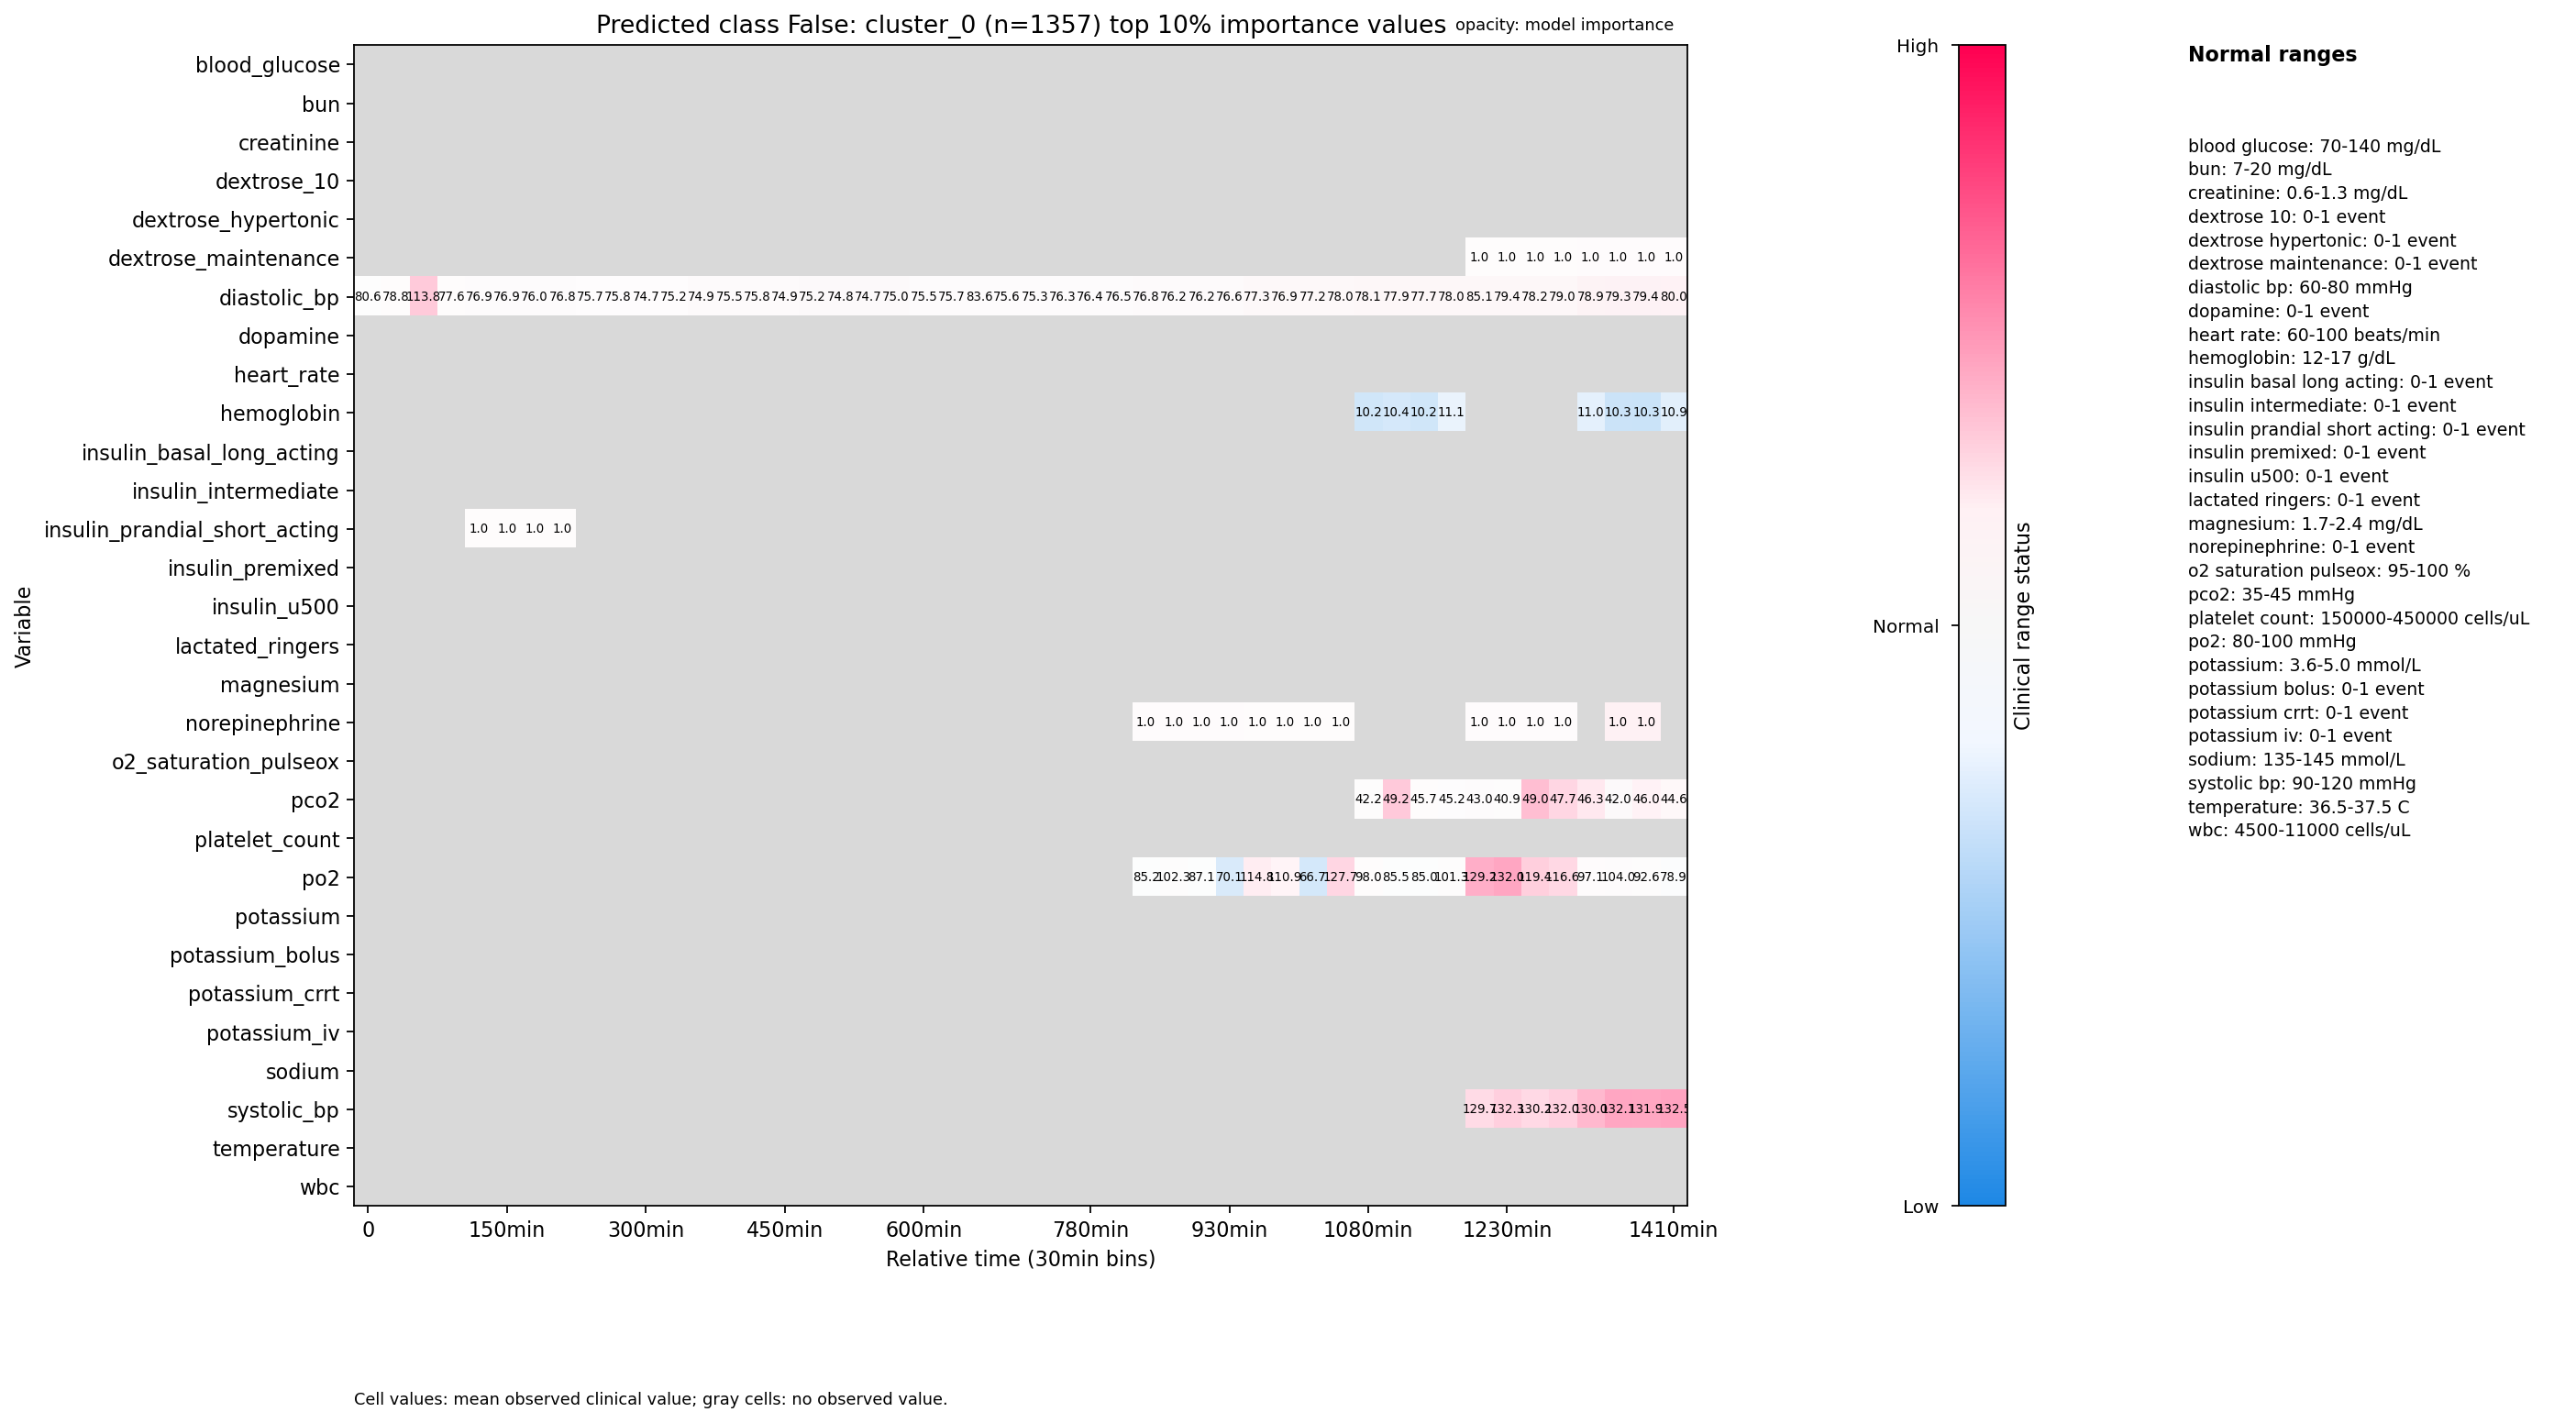

/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/cluster_heatmaps/test/False/cluster_1_top_importance_10pct.png


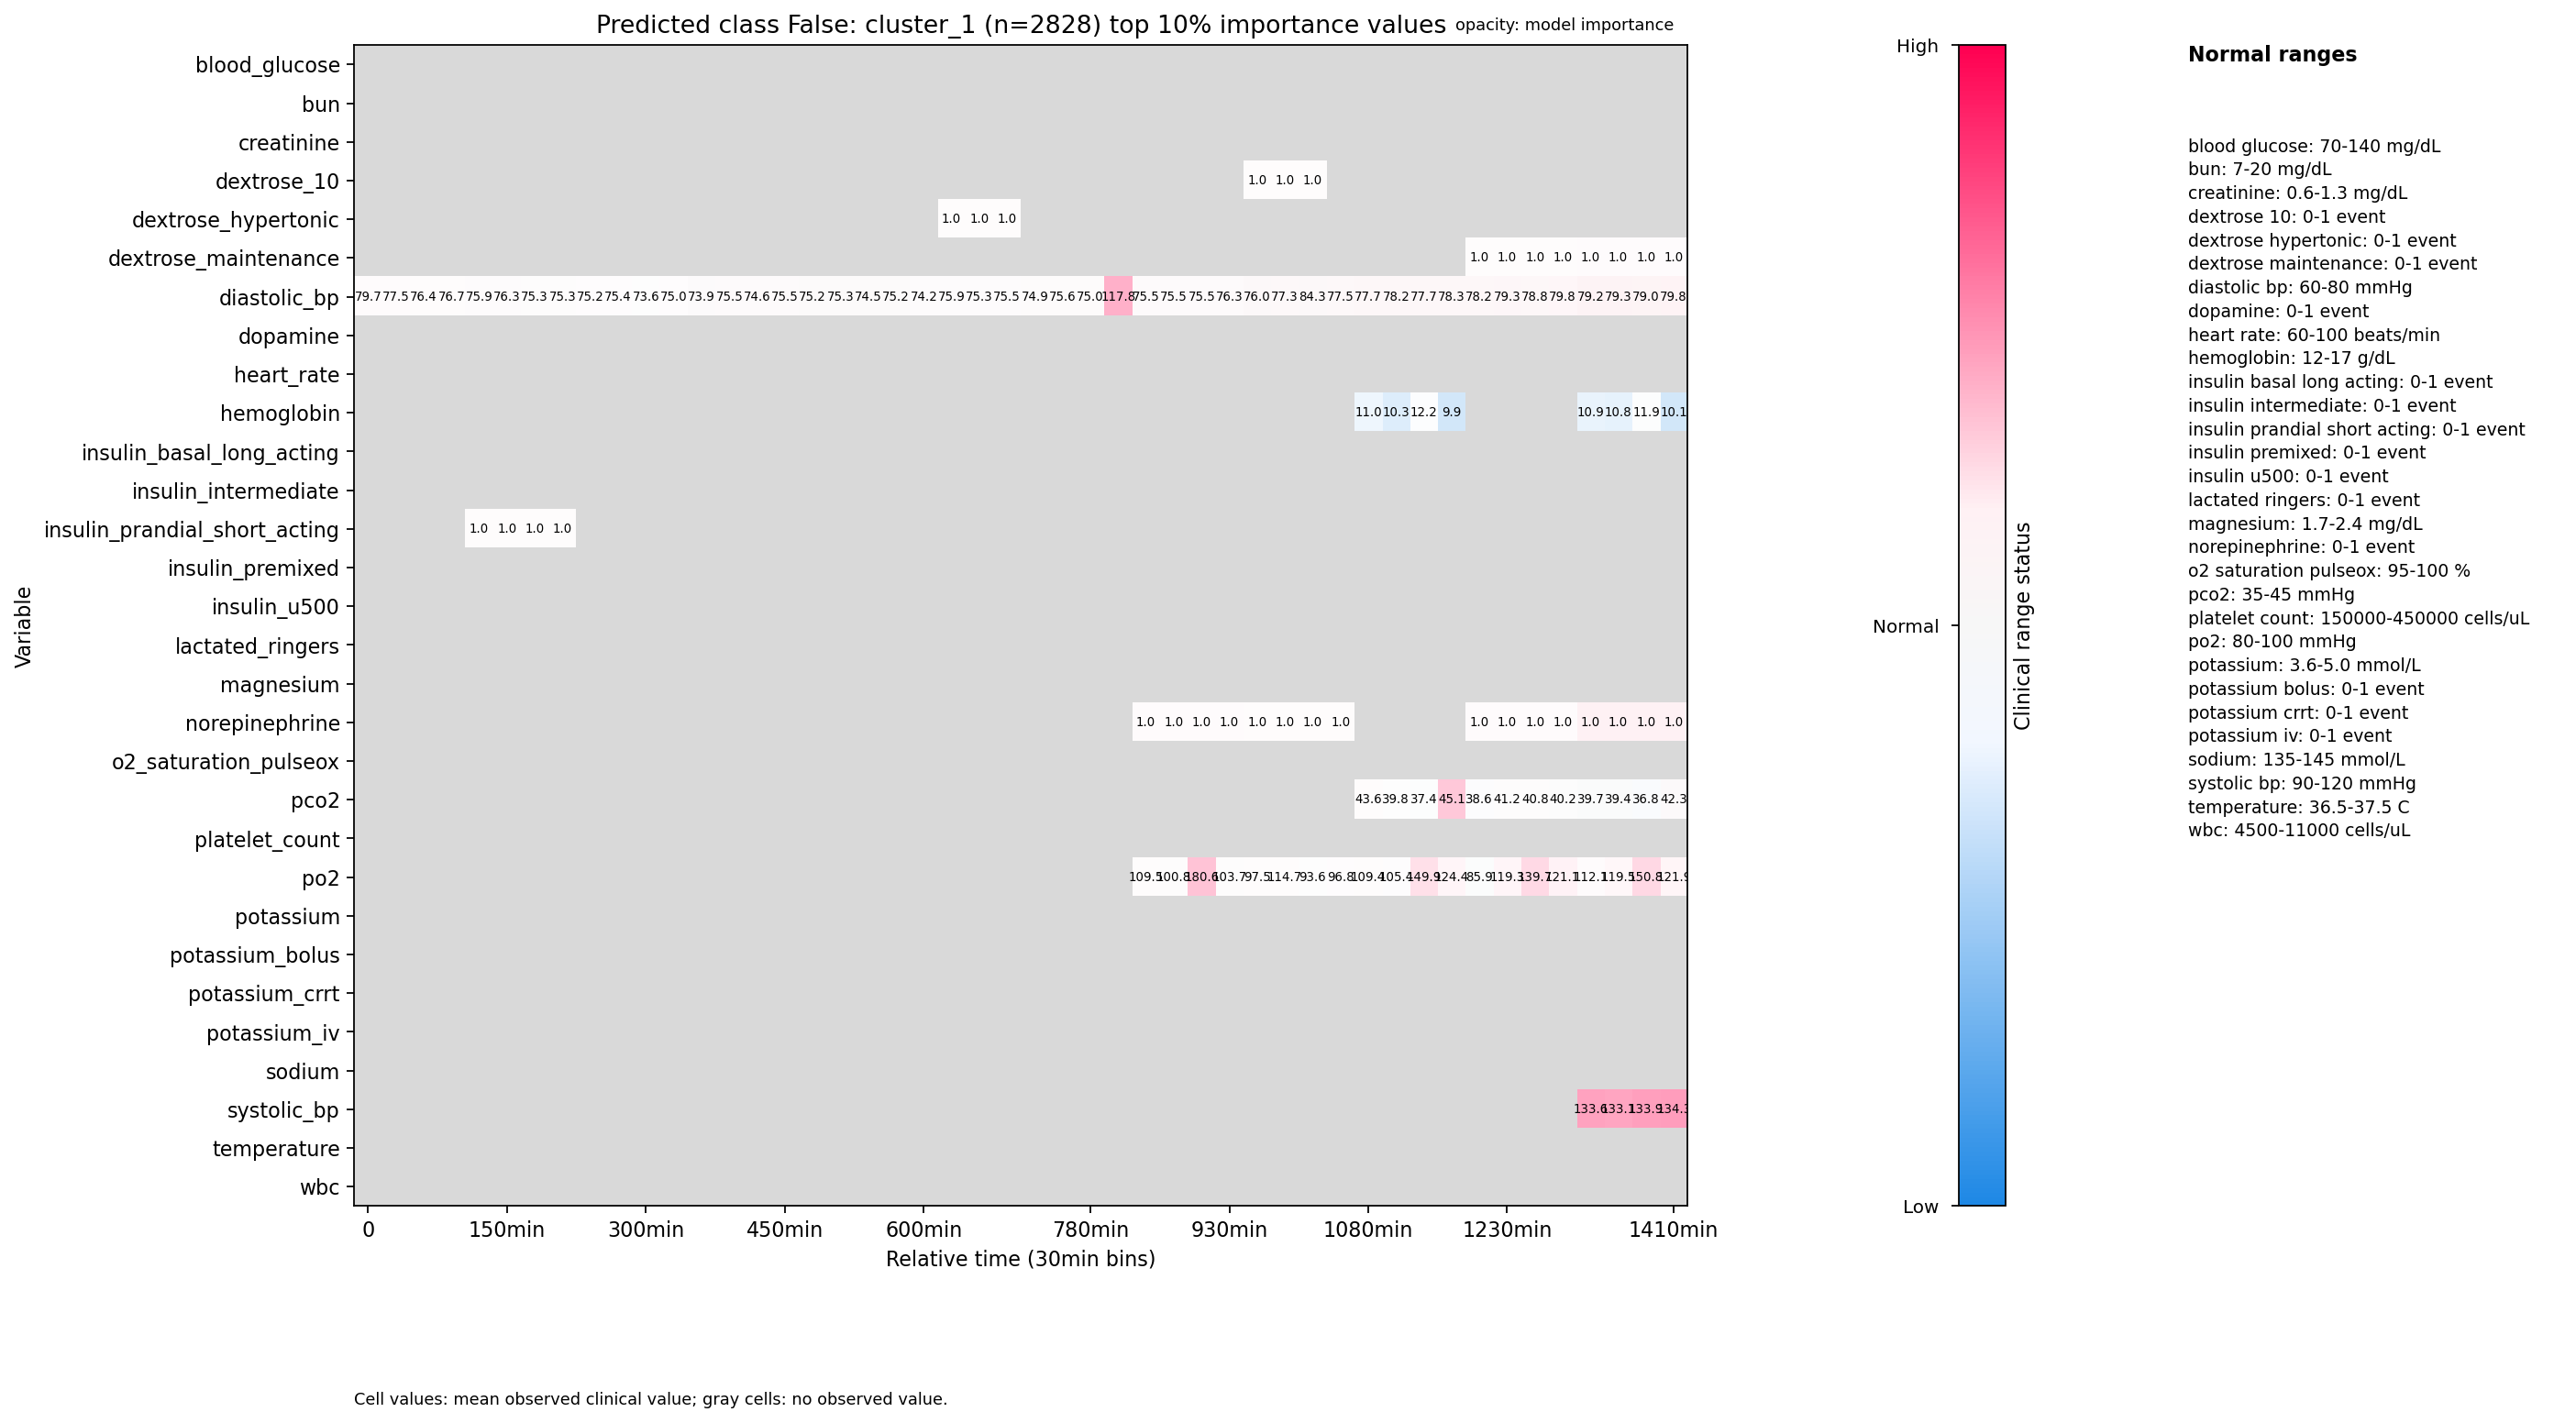

/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/cluster_heatmaps/test/True/cluster_0_top_importance_10pct.png


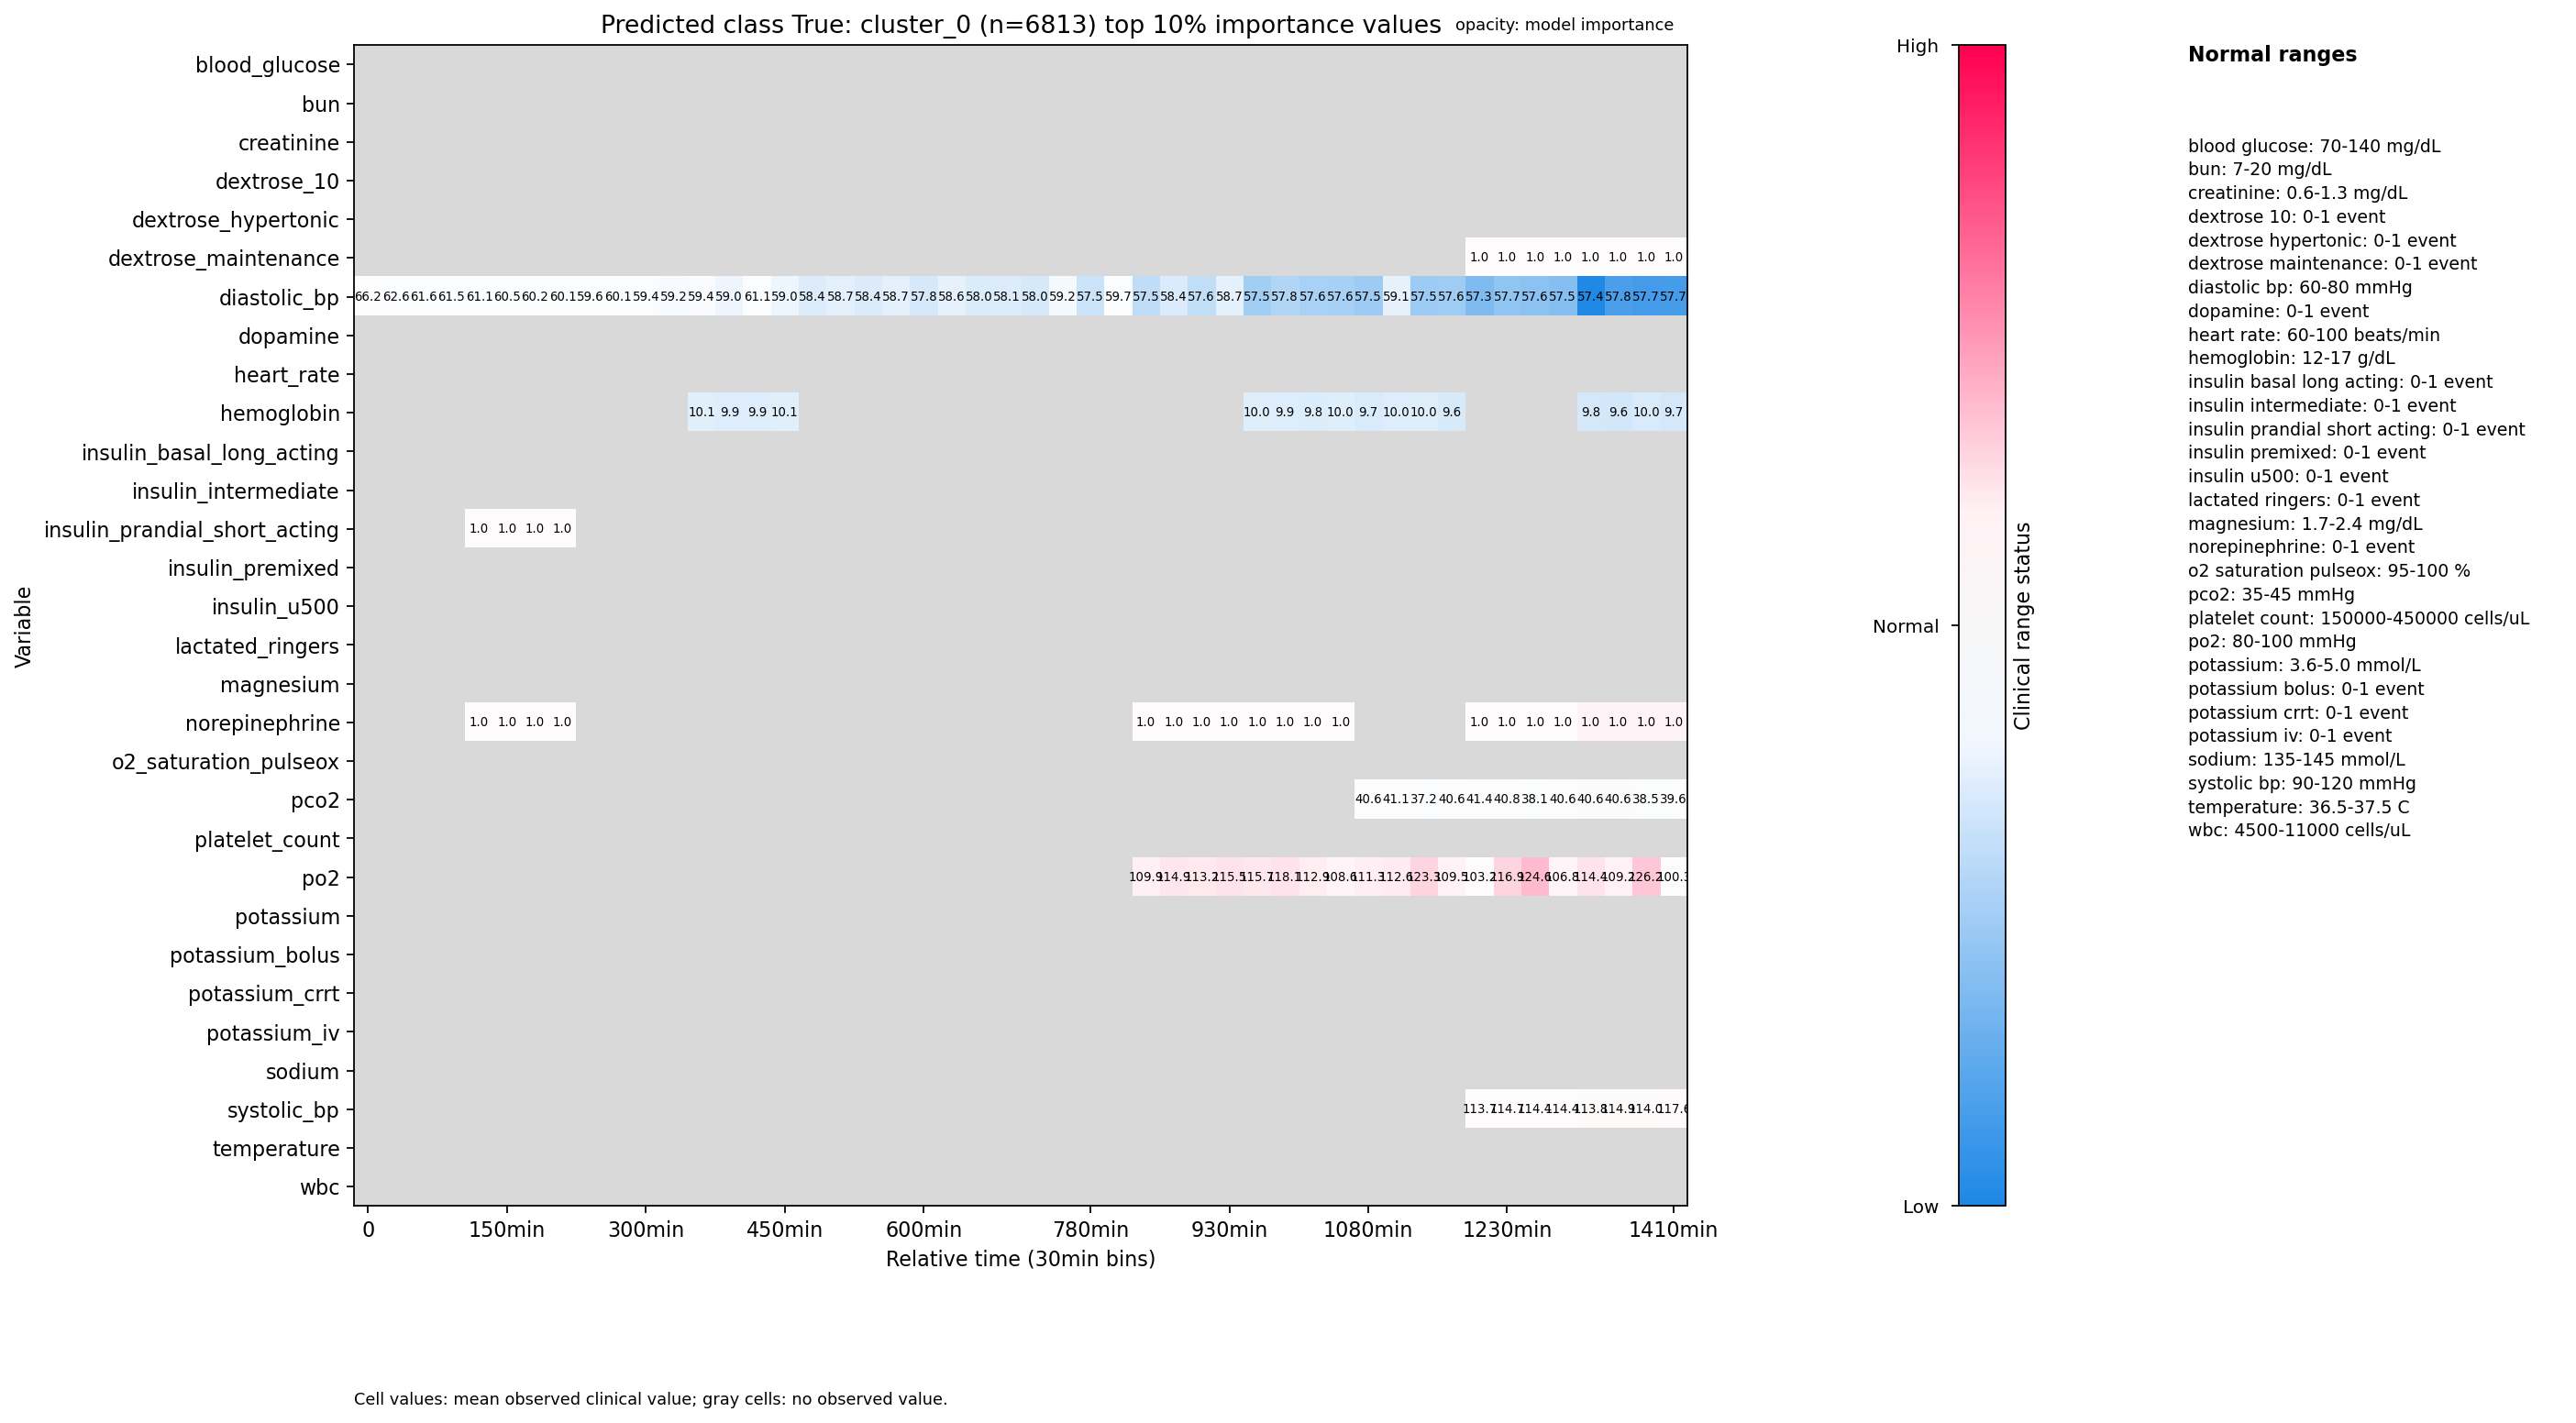

/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/cluster_heatmaps/test/True/cluster_1_top_importance_10pct.png


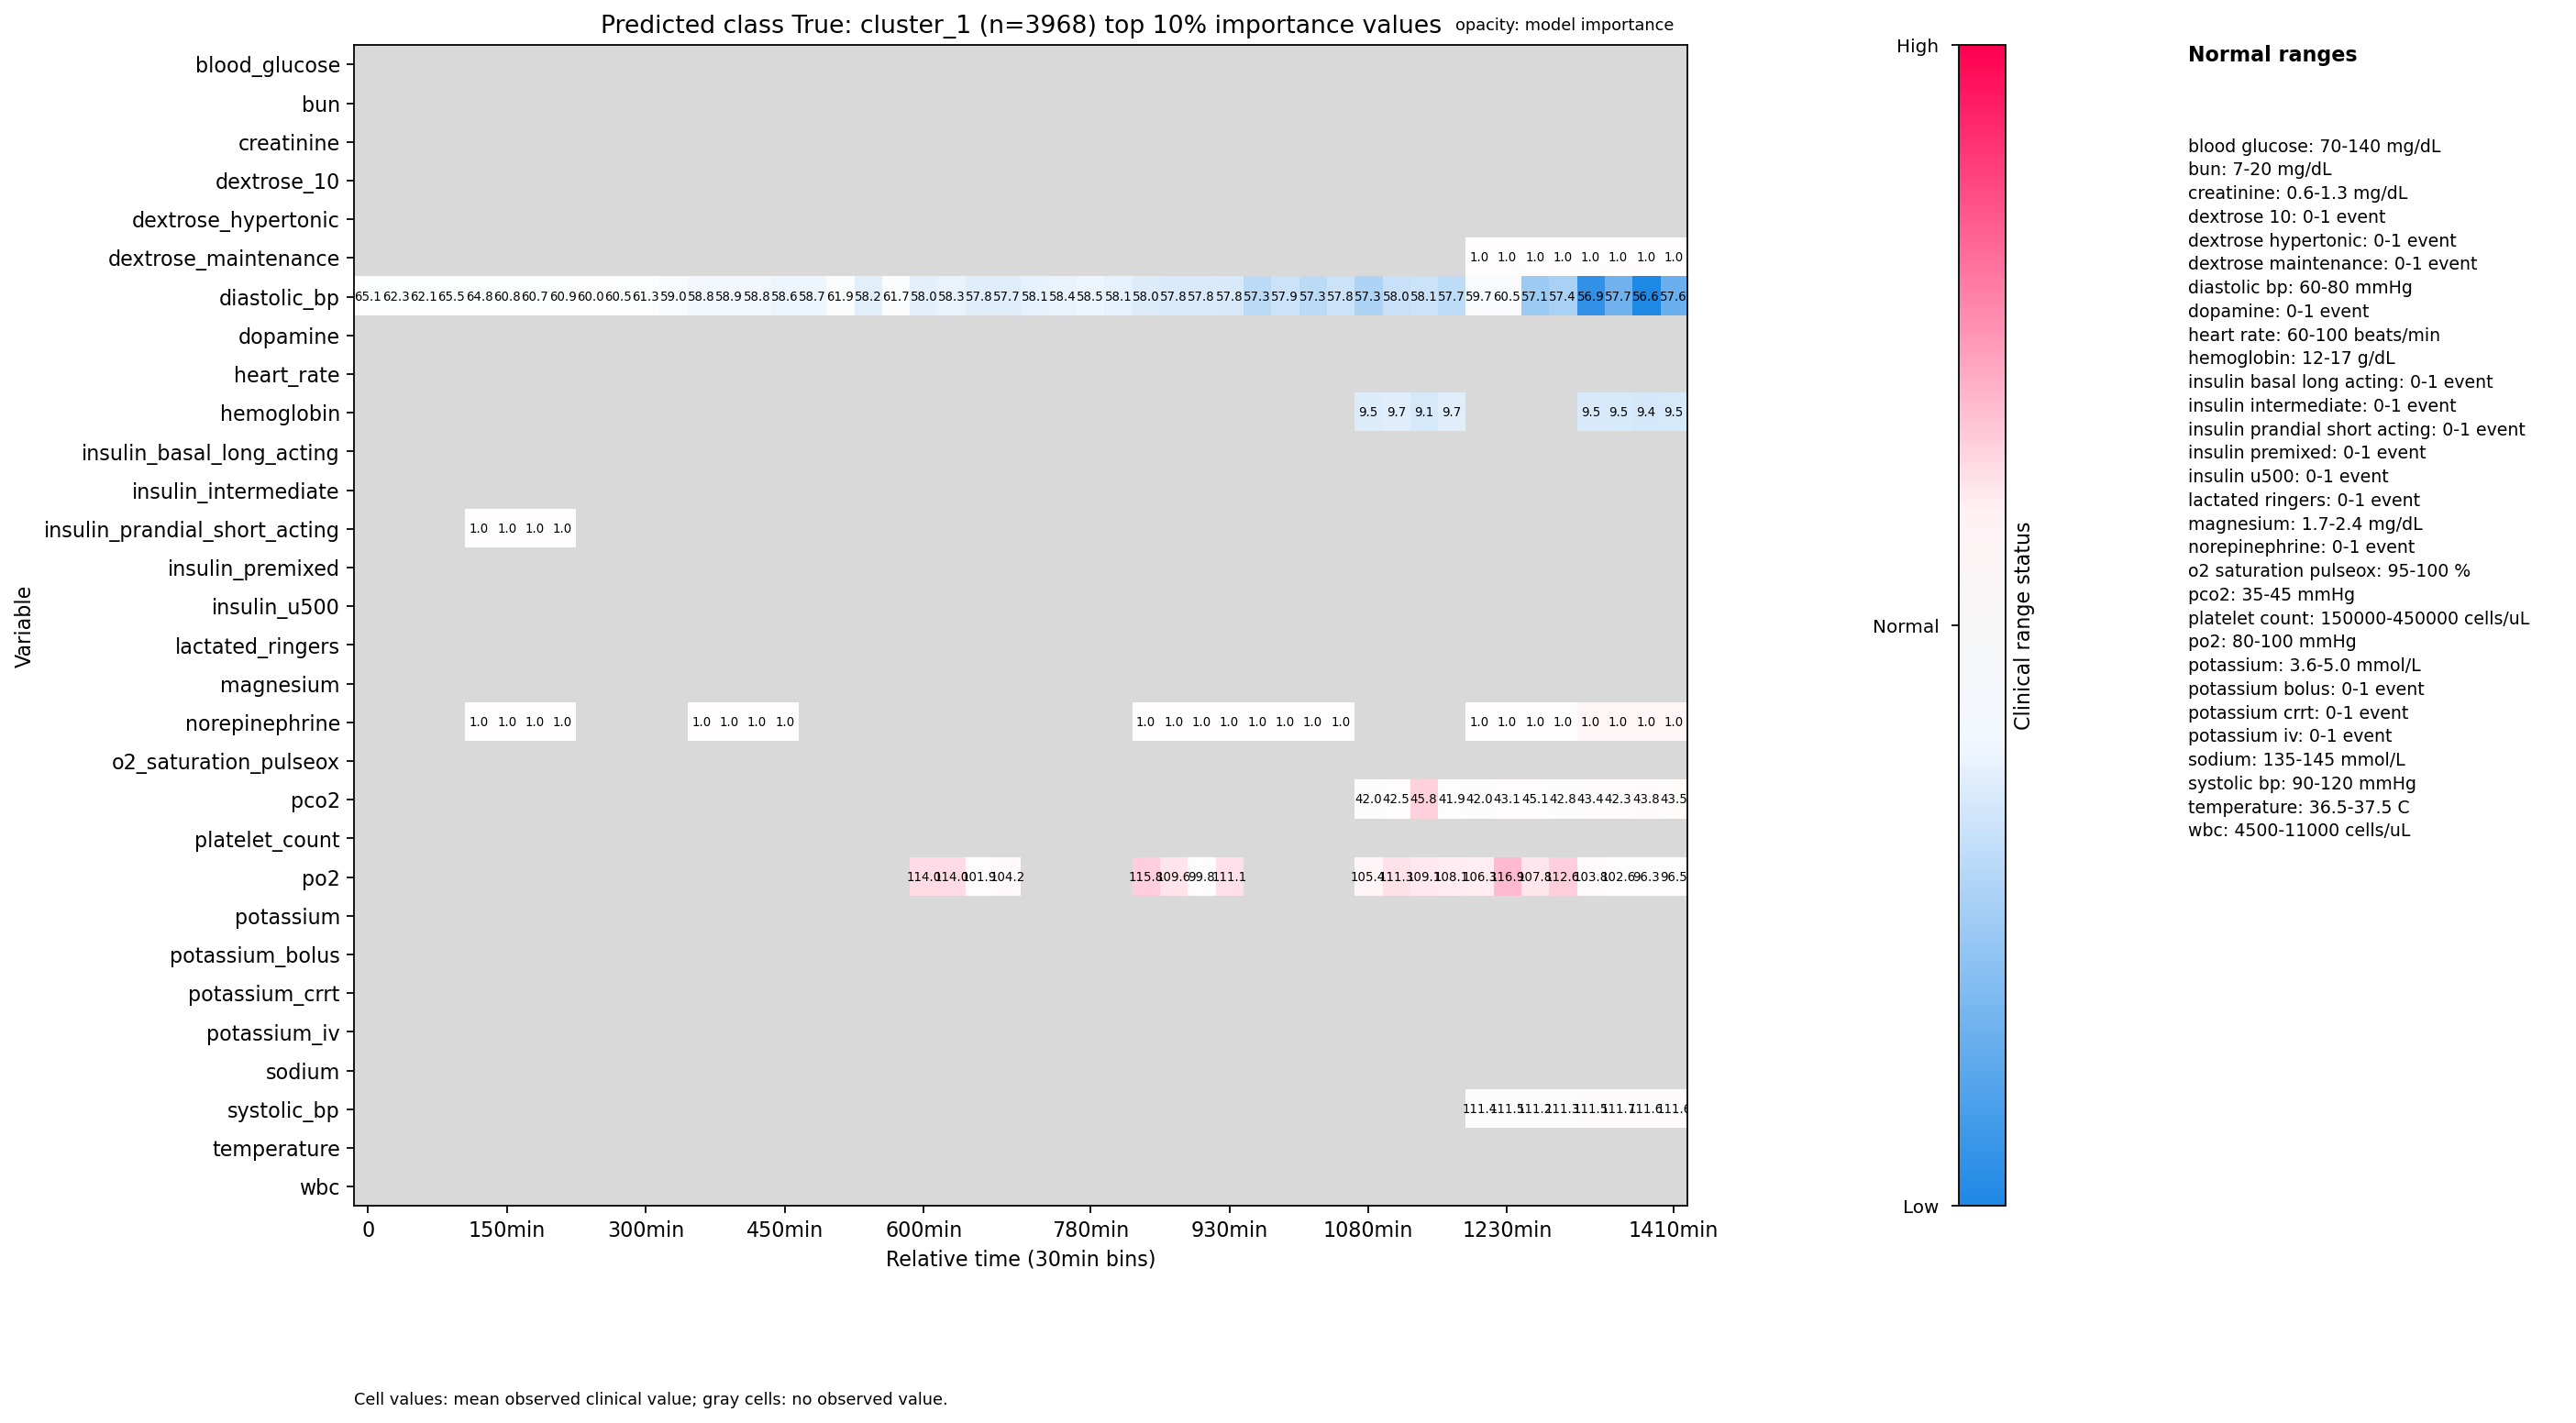

4

In [5]:
all_cluster_heatmaps = plot_all_clusters(
    display_images=True,
    plot_mode="top_importance",
    top_importance_percentage=0.1,
)
len(all_cluster_heatmaps)

/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/selected_cluster_heatmaps/test/True/whole_class_top_importance_10pct.png


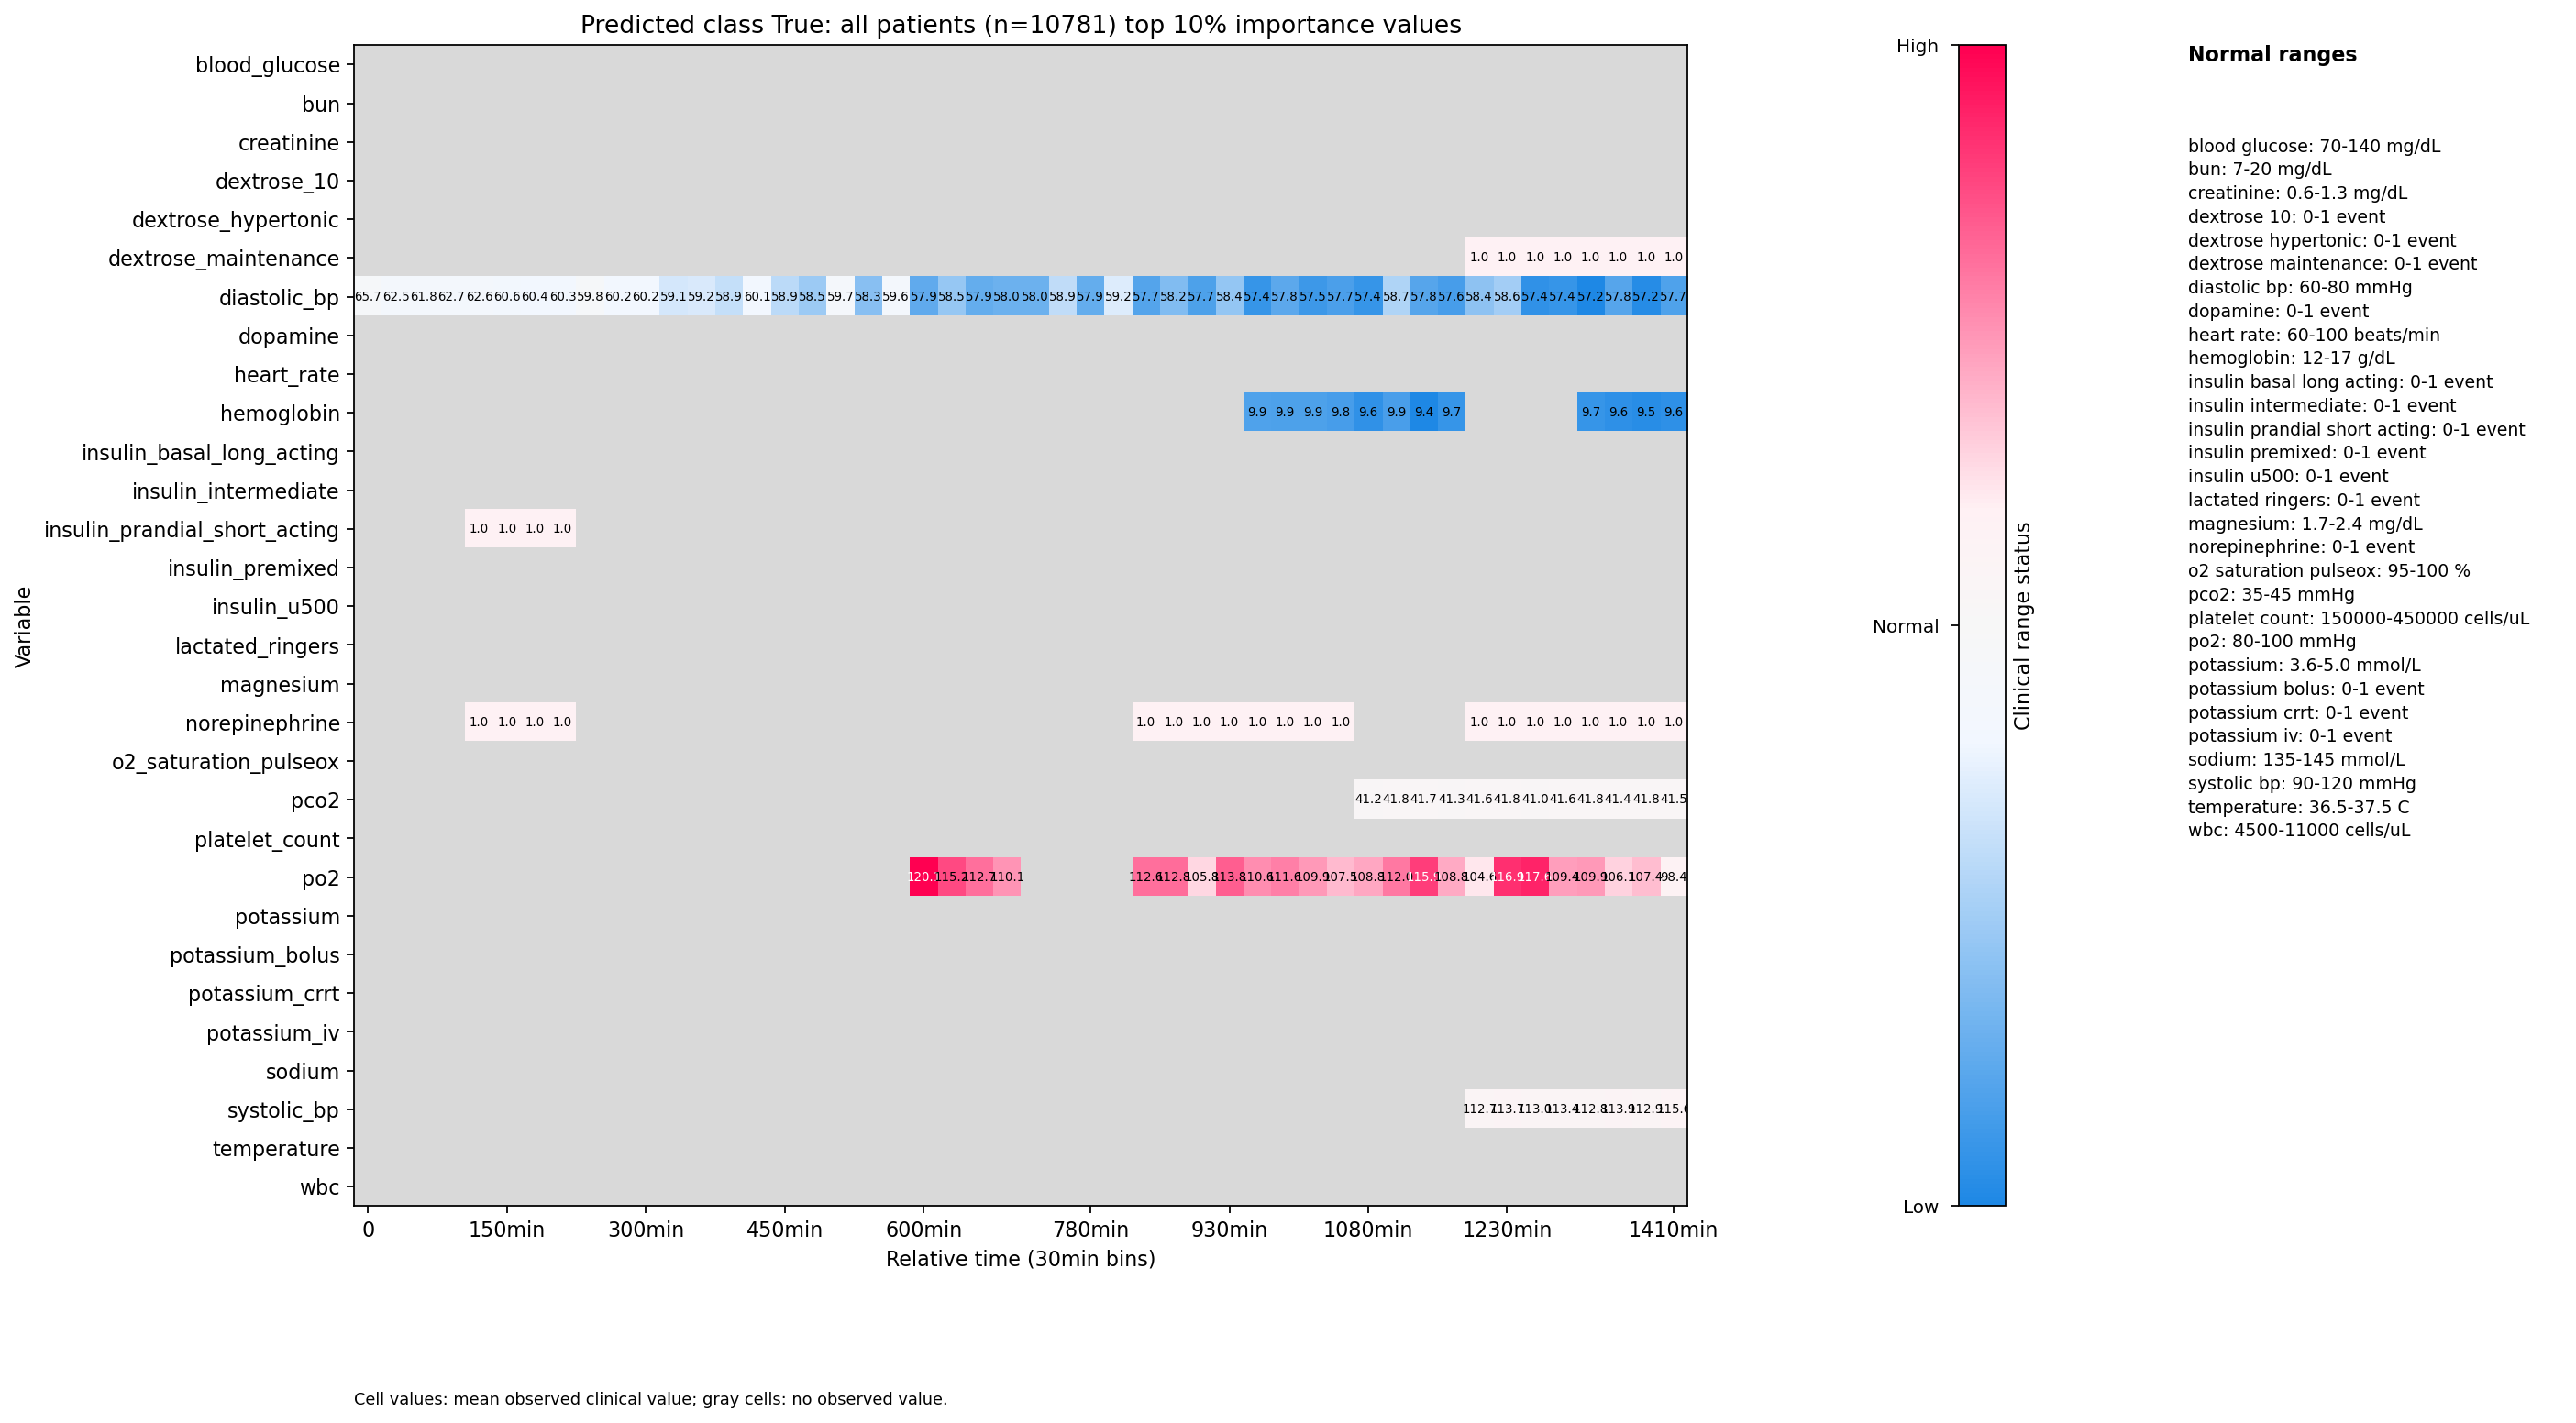

PosixPath('/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/selected_cluster_heatmaps/test/True/whole_class_top_importance_10pct.png')

In [6]:
plot_whole_class("True", plot_mode="top_importance", top_importance_percentage=0.1)

/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/selected_cluster_heatmaps/test/False/whole_class_top_importance_10pct.png


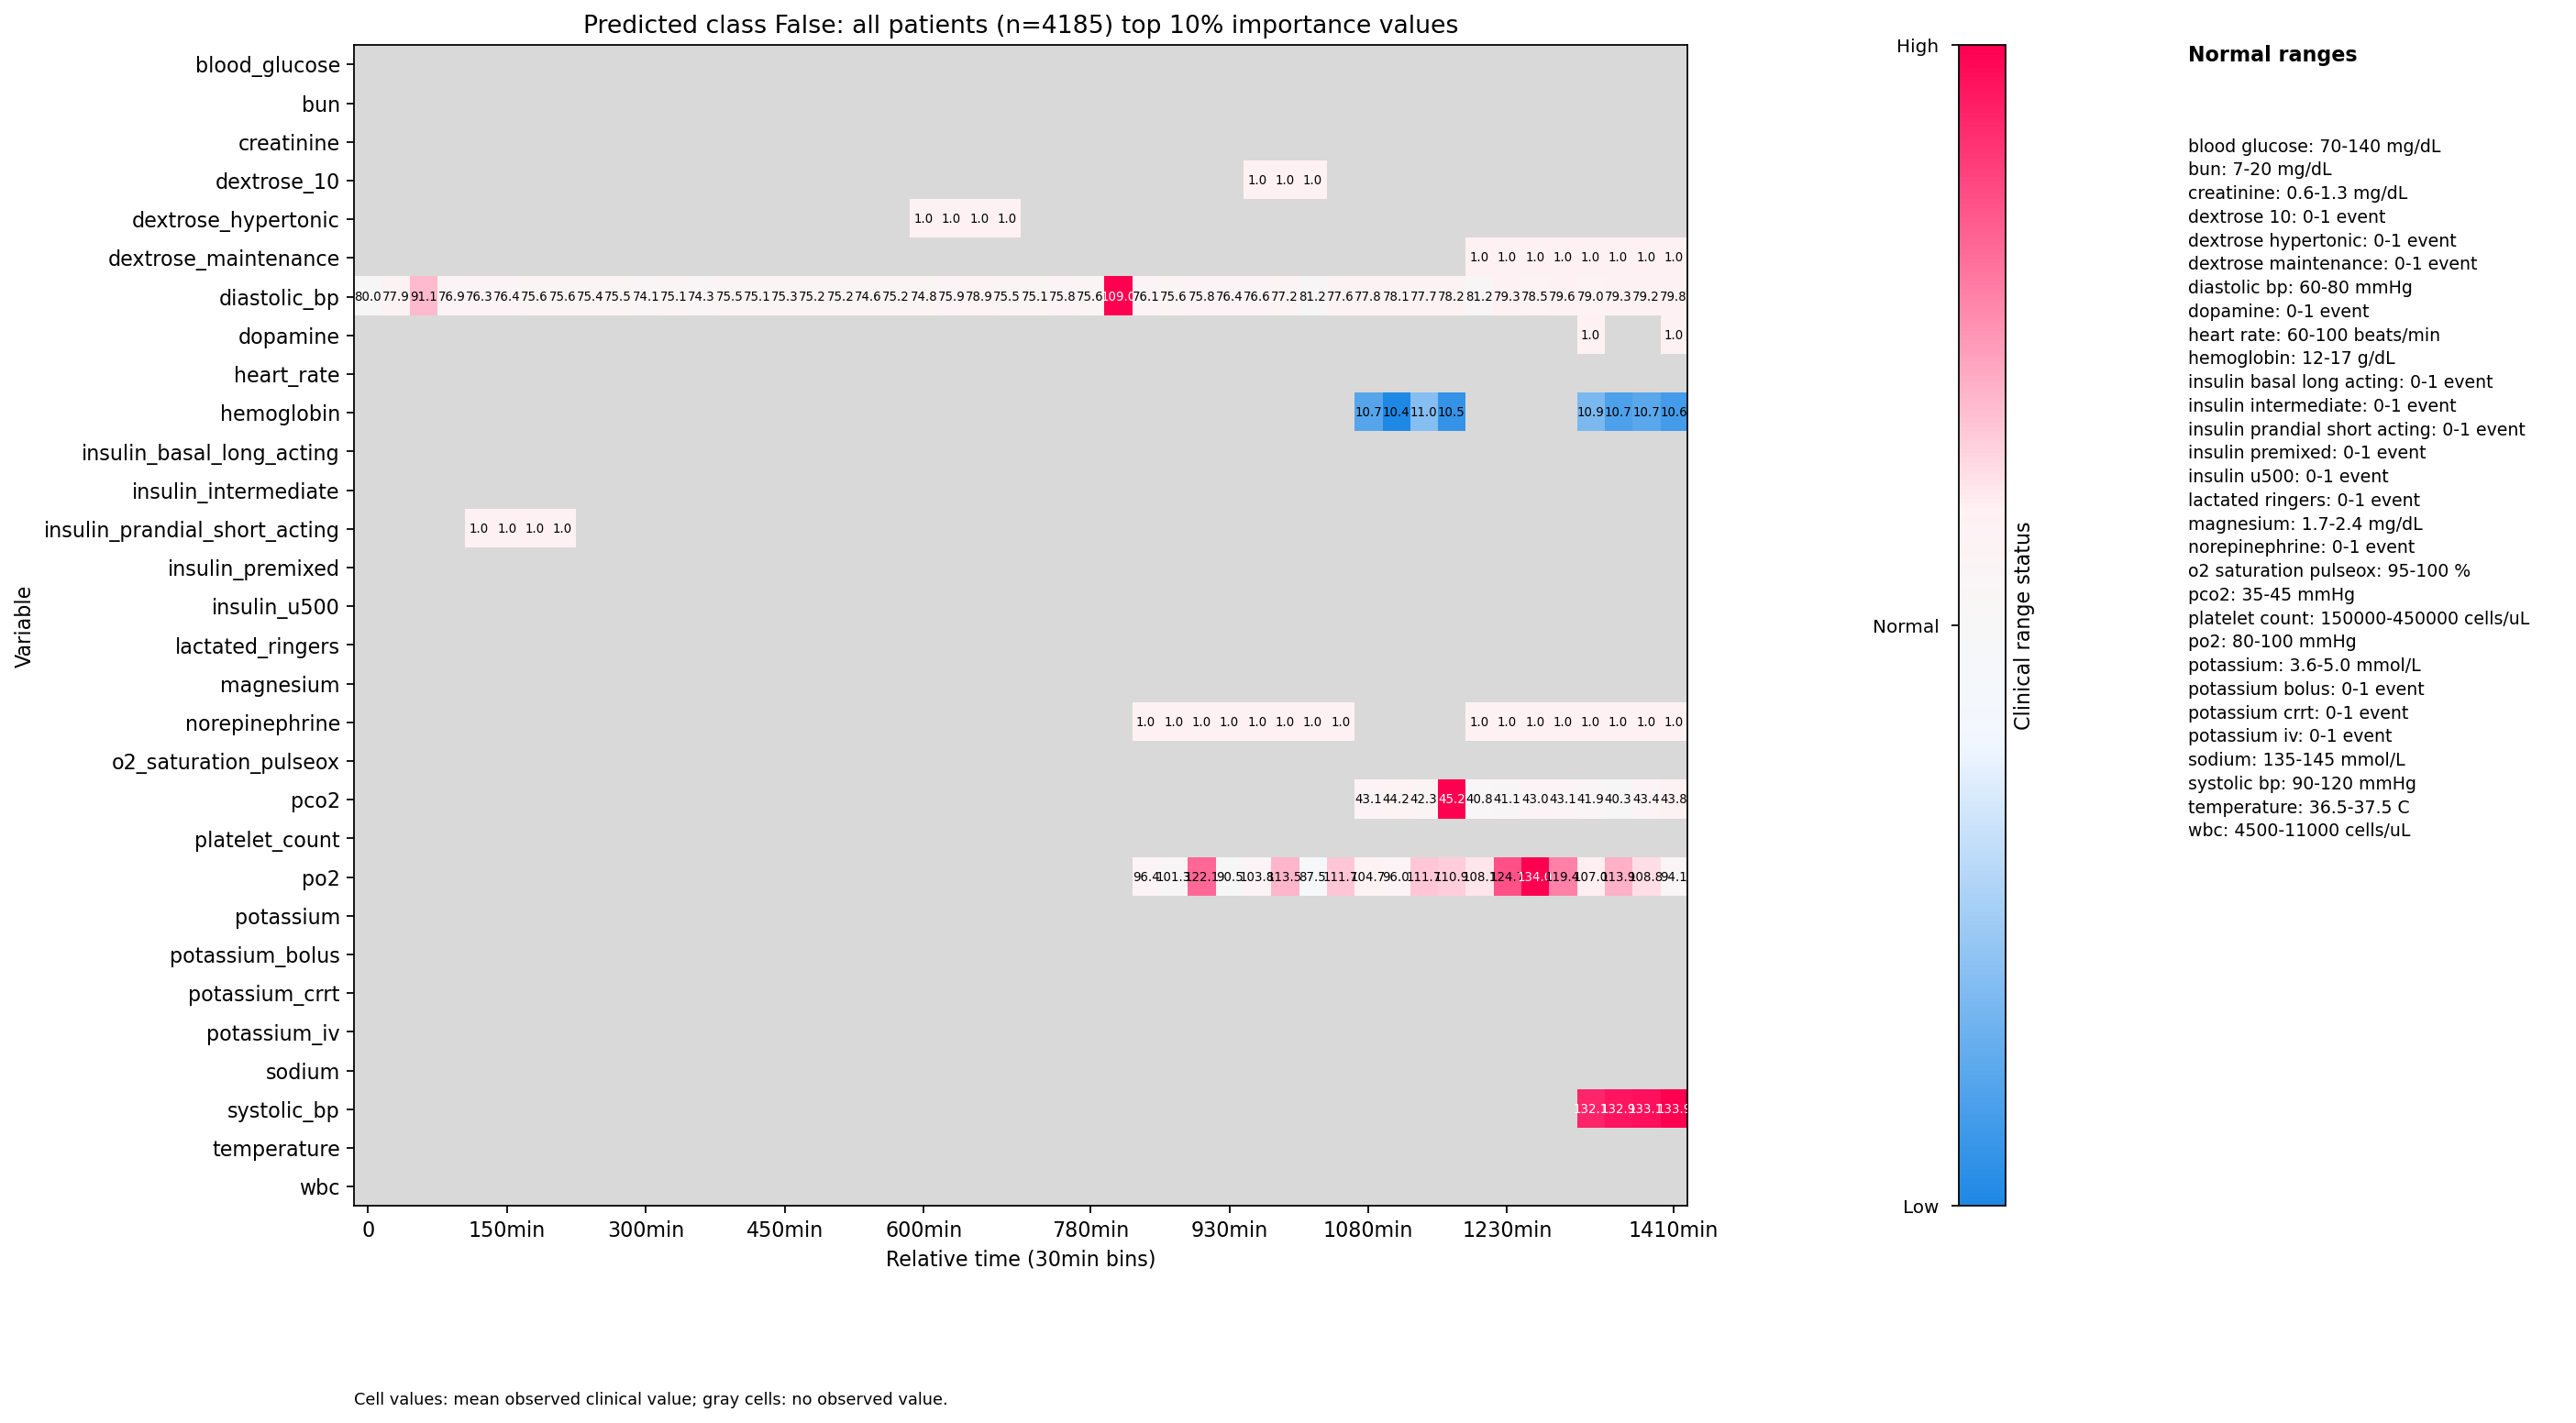

PosixPath('/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/selected_cluster_heatmaps/test/False/whole_class_top_importance_10pct.png')

In [7]:
plot_whole_class("False", plot_mode="top_importance", top_importance_percentage=0.1)

## Whole-Class Pattern Similarity

In [8]:
PATTERN_TOP_IMPORTANCE_PERCENTAGE = 0.1
PATTERN_CLASS_LABELS = ("True", "False")
PATTERN_VALUE_SCALE = "z_score"  # change to "raw" to compare denormalized heatmap values directly


def dataset_value_tensor_for_similarity(dataset, binner, value_scale="z_score"):
    x = dataset.x.detach().cpu().numpy()
    values = x[:, 0].astype(np.float64)
    observed = x[:, 1].astype(bool)
    if value_scale == "raw":
        means = np.array([binner.means_.get(variable, 0.0) for variable in binner.variable_vocab_], dtype=np.float64)[:, None]
        stds = np.array([binner.stds_.get(variable, 1.0) for variable in binner.variable_vocab_], dtype=np.float64)[:, None]
        values = values * stds[None, :, :] + means[None, :, :]
    elif value_scale != "z_score":
        raise ValueError("value_scale must be 'z_score' or 'raw'.")
    return np.where(observed, values, np.nan)


def mean_importance_for_patient_ids(patient_ids):
    total = None
    count = 0
    for patient_id in patient_ids:
        path = EXPLANATIONS_DIR / f"{patient_id}.npy"
        if not path.exists():
            continue
        matrix = np.load(path).astype(np.float64)
        total = matrix if total is None else total + matrix
        count += 1
    if count == 0:
        raise ValueError("No explanation matrices found for the requested patients.")
    return total / count


def nanmean_without_warning(values, axis=0):
    finite = np.isfinite(values)
    counts = finite.sum(axis=axis)
    totals = np.nansum(values, axis=axis)
    result = np.full_like(totals, np.nan, dtype=np.float64)
    np.divide(totals, counts, out=result, where=counts > 0)
    return result


def top_importance_sparse_values(value_matrix, importance_matrix, top_fraction):
    top_fraction = float(top_fraction)
    if not 0.0 < top_fraction <= 1.0:
        raise ValueError("top_fraction must be in (0, 1].")
    finite_mask = np.isfinite(value_matrix) & np.isfinite(importance_matrix)
    finite_importance = importance_matrix[finite_mask]
    if finite_importance.size == 0:
        return np.zeros_like(value_matrix, dtype=np.float64), np.zeros_like(value_matrix, dtype=bool)
    cutoff = np.quantile(finite_importance, 1.0 - top_fraction)
    top_mask = finite_mask & (importance_matrix >= cutoff)
    sparse = np.zeros_like(value_matrix, dtype=np.float64)
    sparse[top_mask] = value_matrix[top_mask]
    return sparse, top_mask


def cosine_similarity(a, b, eps=1e-12):
    a = np.nan_to_num(np.asarray(a, dtype=np.float64).ravel(), nan=0.0)
    b = np.nan_to_num(np.asarray(b, dtype=np.float64).ravel(), nan=0.0)
    denominator = np.linalg.norm(a) * np.linalg.norm(b)
    if denominator <= eps:
        return np.nan
    return float(np.dot(a, b) / denominator)


def more_similar_class(similarity_to_true, similarity_to_false):
    if not np.isfinite(similarity_to_true) or not np.isfinite(similarity_to_false):
        return np.nan
    if similarity_to_true == similarity_to_false:
        return "tie"
    return "True" if similarity_to_true > similarity_to_false else "False"


patient_ids = np.array([str(patient_id) for patient_id in dataset.patient_ids])
patient_to_index = {patient_id: index for index, patient_id in enumerate(patient_ids)}
value_tensor = dataset_value_tensor_for_similarity(dataset, binner, value_scale=PATTERN_VALUE_SCALE)
assignment_labels = assignments[["patient_id", "predicted_label"]].drop_duplicates().copy()
assignment_labels["patient_id"] = assignment_labels["patient_id"].astype(str)
assignment_labels["predicted_label"] = assignment_labels["predicted_label"].astype(str)

class_patterns = {}
class_masks = {}
for class_label in PATTERN_CLASS_LABELS:
    class_patient_ids = assignment_labels.loc[assignment_labels["predicted_label"] == class_label, "patient_id"].tolist()
    class_indices = [patient_to_index[patient_id] for patient_id in class_patient_ids if patient_id in patient_to_index]
    if not class_indices:
        raise ValueError(f"No patients found for predicted_label={class_label!r}.")
    class_mean_values = nanmean_without_warning(value_tensor[class_indices], axis=0)
    class_mean_importance = mean_importance_for_patient_ids(class_patient_ids)
    class_patterns[class_label], class_masks[class_label] = top_importance_sparse_values(
        class_mean_values,
        class_mean_importance,
        PATTERN_TOP_IMPORTANCE_PERCENTAGE,
    )

true_labels = None
if dataset.y is not None:
    y = dataset.y.detach().cpu().numpy().astype(int)
    true_labels = [binner.index_to_label_[label] if 0 <= label < len(binner.index_to_label_) else str(label) for label in y]

rows = []
patient_sparse_patterns = {}
for index, patient_id in enumerate(patient_ids):
    explanation_path = EXPLANATIONS_DIR / f"{patient_id}.npy"
    if not explanation_path.exists():
        continue
    patient_importance = np.load(explanation_path).astype(np.float64)
    patient_pattern, patient_mask = top_importance_sparse_values(
        value_tensor[index],
        patient_importance,
        PATTERN_TOP_IMPORTANCE_PERCENTAGE,
    )
    patient_sparse_patterns[patient_id] = patient_pattern
    similarity_to_true = cosine_similarity(patient_pattern, class_patterns["True"])
    similarity_to_false = cosine_similarity(patient_pattern, class_patterns["False"])
    rows.append({
        "patient_id": patient_id,
        "true_label": None if true_labels is None else str(true_labels[index]),
        "similarity_to_true": similarity_to_true,
        "similarity_to_false": similarity_to_false,
        "more_similar_class": more_similar_class(similarity_to_true, similarity_to_false),
    })

pattern_similarity = pd.DataFrame(rows)
display(pattern_similarity)
display(pattern_similarity[["similarity_to_true", "similarity_to_false"]].describe())

,patient_id,true_label,similarity_to_true,similarity_to_false,more_similar_class
0,30002415,False,-0.035548,0.073352,False
1,30003087,False,-0.033535,0.064693,False
2,30003306,True,0.088815,-0.282869,True
3,30004462,True,0.070288,-0.241356,True
4,30004811,True,0.087029,-0.281141,True
...,...,...,...,...,...
14961,39996044,True,0.116255,-0.142720,True
14962,39996867,False,-0.032833,0.069177,False
14963,39996870,False,0.000000,0.000000,tie
14964,39997370,True,0.039410,-0.185441,True


,similarity_to_true,similarity_to_false
count,14966.000000,14966.000000
mean,0.048352,-0.069041
std,0.071177,0.138835
min,-0.156539,-0.412917
25%,-0.003776,-0.196353
50%,0.034936,-0.048330
75%,0.080262,0.040263
max,0.461538,0.403095


In [9]:
from scipy import stats

SIGNIFICANCE_ALPHA = 0.05

def pattern_class_separation_test(frame, pattern_label, pattern_column, alpha=SIGNIFICANCE_ALPHA):
    other_label = "False" if pattern_label == "True" else "True"
    pattern_class_scores = frame.loc[frame["true_label"].astype(str) == pattern_label, pattern_column].dropna()
    other_class_scores = frame.loc[frame["true_label"].astype(str) == other_label, pattern_column].dropna()
    result = stats.mannwhitneyu(pattern_class_scores, other_class_scores, alternative="greater")
    mean_difference = pattern_class_scores.mean() - other_class_scores.mean()
    winner = np.nan
    if np.isfinite(mean_difference):
        winner = pattern_label if mean_difference > 0 else other_label
    if mean_difference == 0:
        winner = "tie"
    return {
        "pattern": pattern_label,
        "more_similar_class": winner,
        "mean_same_class": float(pattern_class_scores.mean()),
        "mean_other_class": float(other_class_scores.mean()),
        "mean_difference": float(mean_difference),
        "p_value": float(result.pvalue),
        "is_significant": bool((mean_difference > 0) and (result.pvalue < alpha)),
    }


similarity_distribution_tests = pd.DataFrame([
    pattern_class_separation_test(pattern_similarity, "True", "similarity_to_true"),
    pattern_class_separation_test(pattern_similarity, "False", "similarity_to_false"),
])
display(similarity_distribution_tests)

,pattern,more_similar_class,mean_same_class,mean_other_class,mean_difference,p_value,is_significant
0,True,True,0.062759,0.015296,0.047463,0.0,True
1,False,False,-0.006511,-0.096295,0.089785,0.0,True


## Cluster Pattern Similarity Tests

In [10]:
from scipy import stats

SIGNIFICANCE_ALPHA = globals().get("SIGNIFICANCE_ALPHA", 0.05)


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=np.float64)
    adjusted = np.full_like(p_values, np.nan, dtype=np.float64)
    finite = np.isfinite(p_values)
    finite_p_values = p_values[finite]
    if finite_p_values.size == 0:
        return adjusted
    order = np.argsort(finite_p_values)
    ranked = finite_p_values[order]
    corrected = ranked * finite_p_values.size / np.arange(1, finite_p_values.size + 1)
    corrected = np.minimum.accumulate(corrected[::-1])[::-1]
    corrected = np.clip(corrected, 0.0, 1.0)
    finite_adjusted = np.empty_like(corrected)
    finite_adjusted[order] = corrected
    adjusted[finite] = finite_adjusted
    return adjusted


def cluster_pattern_similarity_test(cluster_label, cluster_number, cluster_patient_ids, alpha=SIGNIFICANCE_ALPHA):
    cluster_label = str(cluster_label)
    cluster_number = int(cluster_number)
    other_label = "False" if cluster_label == "True" else "True"
    cluster_indices = [patient_to_index[patient_id] for patient_id in cluster_patient_ids if patient_id in patient_to_index]
    if not cluster_indices:
        raise ValueError(f"No patients found for predicted_label={cluster_label!r}, cluster={cluster_number}.")

    cluster_mean_values = nanmean_without_warning(value_tensor[cluster_indices], axis=0)
    cluster_mean_importance = mean_importance_for_patient_ids(cluster_patient_ids)
    cluster_pattern, cluster_mask = top_importance_sparse_values(
        cluster_mean_values,
        cluster_mean_importance,
        PATTERN_TOP_IMPORTANCE_PERCENTAGE,
    )

    scores = pattern_similarity[["patient_id", "true_label"]].copy()
    scores["similarity"] = [
        cosine_similarity(patient_sparse_patterns[patient_id], cluster_pattern)
        for patient_id in scores["patient_id"].astype(str)
    ]
    same_class_scores = scores.loc[scores["true_label"].astype(str) == cluster_label, "similarity"].dropna()
    other_class_scores = scores.loc[scores["true_label"].astype(str) == other_label, "similarity"].dropna()
    mean_difference = same_class_scores.mean() - other_class_scores.mean()
    winner = np.nan
    if np.isfinite(mean_difference):
        winner = cluster_label if mean_difference > 0 else other_label
    if mean_difference == 0:
        winner = "tie"
    p_value = np.nan
    if len(same_class_scores) > 0 and len(other_class_scores) > 0:
        result = stats.mannwhitneyu(same_class_scores, other_class_scores, alternative="greater")
        p_value = float(result.pvalue)

    return {
        "pattern_class": cluster_label,
        "cluster": cluster_number,
        "more_similar_class": winner,
        "cluster_size": int(len(cluster_patient_ids)),
        "n_same_class": int(len(same_class_scores)),
        "n_other_class": int(len(other_class_scores)),
        "mean_same_class": float(same_class_scores.mean()),
        "mean_other_class": float(other_class_scores.mean()),
        "mean_difference": float(mean_difference),
        "p_value": p_value,
        "is_significant_raw": bool((mean_difference > 0) and np.isfinite(p_value) and (p_value < alpha)),
    }


cluster_similarity_distribution_tests = pd.DataFrame([
    cluster_pattern_similarity_test(predicted_label, cluster, group["patient_id"].astype(str).tolist())
    for (predicted_label, cluster), group in assignments.groupby(["predicted_label", "cluster"], sort=True)
]).sort_values(["pattern_class", "cluster"]).reset_index(drop=True)
cluster_similarity_distribution_tests["p_value_bh"] = benjamini_hochberg(cluster_similarity_distribution_tests["p_value"])
cluster_similarity_distribution_tests["is_significant_bh"] = (
    (cluster_similarity_distribution_tests["mean_difference"] > 0)
    & (cluster_similarity_distribution_tests["p_value_bh"] < SIGNIFICANCE_ALPHA)
)

display(cluster_similarity_distribution_tests)

,pattern_class,cluster,more_similar_class,cluster_size,n_same_class,n_other_class,mean_same_class,mean_other_class,mean_difference,p_value,is_significant_raw,p_value_bh,is_significant_bh
0,False,0,False,1357,4543,10423,-0.003171,-0.070694,0.067523,0.0,True,0.0,True
1,False,1,False,2828,4543,10423,-0.012170,-0.096895,0.084725,0.0,True,0.0,True
2,True,0,True,6813,10423,4543,0.055791,0.010022,0.045769,0.0,True,0.0,True
3,True,1,True,3968,10423,4543,0.071227,0.019626,0.051601,0.0,True,0.0,True


## Plot Tested Class and Cluster Patterns

In [ ]:
PATTERN_PLOT_MODE = "top_importance"
PATTERN_PLOT_TOP_IMPORTANCE_PERCENTAGE = PATTERN_TOP_IMPORTANCE_PERCENTAGE

available_pattern_classes = [
    class_label
    for class_label in PATTERN_CLASS_LABELS
    if class_label in set(assignments["predicted_label"].astype(str))
]

class_pattern_paths = [
    plot_whole_class(
        class_label,
        plot_mode=PATTERN_PLOT_MODE,
        top_importance_percentage=PATTERN_PLOT_TOP_IMPORTANCE_PERCENTAGE,
    )
    for class_label in available_pattern_classes
]

cluster_pattern_paths = plot_all_clusters(
    display_images=True,
    plot_mode=PATTERN_PLOT_MODE,
    top_importance_percentage=PATTERN_PLOT_TOP_IMPORTANCE_PERCENTAGE,
)

display(pd.DataFrame(
    [{"pattern_type": "class", "path": str(path)} for path in class_pattern_paths]
    + [{"pattern_type": "cluster", "path": str(path)} for path in cluster_pattern_paths]
))

## Plot One Cluster

In [6]:
# Choose any available predicted_label / cluster pair from the table above.
# patient_ids_by_cluster[("True", 0)][:20]
# patients_in_cluster("True", 0).head()
# plot_selected_cluster("True", 0)
# plot_whole_class("True")
# plot_whole_class("True", plot_mode="top_importance", top_importance_percentage=0.1)
# plot_selected_cluster("True", 0, plot_mode="top_importance", top_importance_percentage=0.1)
# plot_all_clusters(plot_mode="top_importance", top_importance_percentage=0.1)
# plot_patient_from_cluster("True", 0)  # defaults to the centroid patient and global PLOT_MODE
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="values")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="importance")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="top_importance", top_importance_percentage=0.1)
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined")  # default: importance_encoding="contour"
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="contour")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="markers")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="side_strip")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="spotlight")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="pattern")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="yellow_glow")
# plot_cluster_and_patient("False", 3)
# plot_cluster_and_patient("True", 0, patient_id="30024067", plot_mode="top_importance", top_importance_percentage=0.1)

In [ ]:
plot_whole_class("True", plot_mode="top_importance", top_importance_percentage=0.1)

## Artifact Check

In [ ]:
important_artifacts = [
    CLUSTERS_DIR / "autoencoder_embeddings.csv",
    CLUSTERS_DIR / "cluster_assignments.csv",
    CLUSTERS_DIR / "cluster_centroids.csv",
    CLUSTERS_DIR / "cluster_metadata.json",
    OUTPUT_DIR,
    SELECTED_OUTPUT_DIR,
    SELECTED_PATIENT_OUTPUT_DIR,
]
display(pd.DataFrame({"exists": [path.exists() for path in important_artifacts], "path": [str(path) for path in important_artifacts]}))